# 03 — Cartesian Grid, CAPPI, CRS and GIS Integration
## DRRAA Omkoi S-band Weather Radar

**Teaching case**

- Radar site: **Omkoi**
- Radar band: **S-band**
- Radar altitude: **1,173 m MSL**
- Volume scan: **14 elevation angles (0.5°–19.5°)**
- Gate spacing: **500 m**
- Approximate azimuth sampling: **~1.06°**
- Maximum range: **~237 km**
- Canonical scientific time: **UTC**
- Local interpretation time: **ICT**

---

## Why this Notebook matters

Notebook 02 worked mainly with native PPI data.

Notebook 03 makes the key transition:

```text
Polar radar observations
        ↓
3-D Cartesian interpolation
        ↓
CAPPI
        ↓
coverage diagnostics
        ↓
longitude / latitude
        ↓
UTM
        ↓
GeoTIFF / GIS
```

> **Core scientific principles**
>
> `Radar gate ≠ Cartesian pixel`
>
> `Interpolation ≠ direct observation`
>
> `Grid spacing ≠ observational resolution`
>
> `PPI ≠ CAPPI`

# Learning outcomes

เมื่อจบ Notebook 03 ผู้เรียนควรสามารถ:

1. อธิบาย polar radar coordinates และ Cartesian coordinates
2. อธิบายว่าการ gridding เป็น interpolation
3. เลือก horizontal/vertical grid spacing โดยอ้างอิง radar sampling
4. แยก ARL, MSL และ AGL
5. สร้าง 3-D Py-ART Grid ด้วย parameter ที่ explicit
6. ทำให้ `grid.z` อ้างอิง **MSL โดยตรง**
7. ตรวจ grid geometry, projection, data support และ memory footprint
8. สกัด CAPPI ที่หลายระดับความสูง
9. สร้าง publication-ready CAPPI + ADM1/ADM2
10. วิเคราะห์ ROI sensitivity
11. วิเคราะห์ grid-spacing sensitivity
12. แปลงพิกัด Cartesian ↔ lon/lat ↔ UTM
13. สกัด reflectivity ที่ geographic point
14. export CAPPI เป็น GeoTIFF
15. reproject GeoTIFF เป็น UTM
16. reopen/validate GeoTIFF independently
17. save 3-D Grid เป็น NetCDF
18. export metadata + figure manifest เพื่อ reproducibility

# Conceptual workflow

```text
Validated UF volume
     ↓
GateFilter
     ↓
Py-ART grid_from_radars
     ↓
3-D corrected-reflectivity grid
     │
     ├── x/y: metres from radar-centered origin
     └── z: metres MSL in this Notebook
     ↓
CAPPI levels
     ↓
coverage / interpolation diagnostics
     ↓
GIS + CRS
     ↓
GeoTIFF / NetCDF / point extraction
```

# 1. Install / check the Google Colab environment

In [1]:
# CELL 1 — Install Notebook 03 packages

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "geopandas>=1.0",
    "pyogrio>=0.10",
    "cartopy>=0.23",
    "pyproj>=3.6",
    "shapely>=2.0",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "netCDF4>=1.6",
    "rasterio>=1.4",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("Installing / checking Notebook 03 libraries ...")
subprocess.check_call(cmd)
print("Environment ready.")

Installing / checking Notebook 03 libraries ...
Environment ready.


# 2. Mount Google Drive

In [2]:
# CELL 2 — Mount Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()
    print("google.colab not detected.")
    print("Using:", DRIVE_ROOT)

Mounted at /content/drive


# 3. Imports and software versions

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import gzip
import json
import shutil
import sys
import tempfile
import time
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib
import matplotlib.pyplot as plt

import cartopy
import cartopy.crs as ccrs

import pyart
import pyproj
from pyproj import CRS, Transformer

import rasterio
from rasterio.transform import from_origin
from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling,
)

from netCDF4 import num2date
from IPython.display import display

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pyart": pyart.__version__,
    "geopandas": gpd.__version__,
    "cartopy": cartopy.__version__,
    "pyproj": pyproj.__version__,
    "rasterio": rasterio.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=["software", "version"],
    )
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,geopandas,1.1.4
6,cartopy,0.25.0
7,pyproj,3.7.2
8,rasterio,1.5.1


# 4. Publication-quality plotting and figure provenance

In [4]:
# CELL 4 — Plot defaults + figure manifest

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    *,
    source_file=None,
    field=None,
    height_msl_km=None,
    time_utc=None,
    processing=None,
    vmin=None,
    vmax=None,
    cmap=None,
    dpi=300,
):
    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": path.name,
        "figure_path": str(path),
        "source_file": source_file,
        "field": field,
        "height_msl_km": height_msl_km,
        "time_UTC": (
            str(time_utc)
            if time_utc is not None
            else None
        ),
        "processing": processing,
        "vmin": vmin,
        "vmax": vmax,
        "colormap": cmap,
        "dpi": dpi,
    })

    print("Saved figure:", path)

# 5. Load the validated Notebook 01–02 workspace

Notebook 03 will stop if Notebook 02 is not fully READY.

In [5]:
# CELL 5 — Load Notebook 01 state

COURSE_NAME = "Teaching_DRRAA_WeatherRadar_GIS"

ROOT = DRIVE_ROOT / COURSE_NAME

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

SETUP_STATUS_JSON = (
    ROOT
    / "99_logs"
    / "01_setup_status.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "course_config.json missing. "
        "Run Notebook 01 first."
    )

if not SETUP_STATUS_JSON.exists():
    raise FileNotFoundError(
        "01_setup_status.json missing. "
        "Run Notebook 01 first."
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(stream)

with SETUP_STATUS_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    SETUP_STATUS = json.load(stream)

if not SETUP_STATUS.get("ready", False):
    raise RuntimeError(
        "Notebook 01 dataset is not READY."
    )

print("Notebook 01 readiness: PASS")

Notebook 01 readiness: PASS


In [6]:
# CELL 6 — Paths and Notebook 02 readiness

WORKSPACE = COURSE_CONFIG["workspace"]

RADAR_DIR = Path(
    WORKSPACE["radar"]
)

GIS_CANONICAL_DIR = Path(
    WORKSPACE["gis_canonical"]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE["output_csv"]
)

OUTPUT_GEOTIFF_DIR = Path(
    WORKSPACE["output_geotiff"]
)

OUTPUT_GPKG_DIR = Path(
    WORKSPACE["output_gpkg"]
)

OUTPUT_NETCDF_DIR = (
    ROOT
    / "03_output"
    / "netcdf"
)

FIGURE_DIR = (
    ROOT
    / "04_figures"
    / "03"
)

for folder in [
    OUTPUT_CSV_DIR,
    OUTPUT_GEOTIFF_DIR,
    OUTPUT_GPKG_DIR,
    OUTPUT_NETCDF_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

READINESS_02_CSV = (
    OUTPUT_CSV_DIR
    / "02_readiness_check.csv"
)

if not READINESS_02_CSV.exists():
    raise FileNotFoundError(
        "02_readiness_check.csv missing. "
        "Run Notebook 02 first."
    )

readiness_02 = pd.read_csv(
    READINESS_02_CSV
)

display(readiness_02)

if not (
    readiness_02["status"]
    == "PASS"
).all():
    raise RuntimeError(
        "Notebook 02 has failed checks."
    )

print("Notebook 02 readiness: PASS")

,item,status,note
0,Notebook 01 dataset readiness,PASS,NaN
1,Selected radar readable,PASS,NaN
2,Raw reflectivity available,PASS,NaN
3,Corrected reflectivity available,PASS,NaN
4,Velocity available,PASS,NaN
5,Spectrum width available,PASS,NaN
6,Nyquist velocity available,PASS,NaN
7,Dealiased velocity created,PASS,NaN
8,ADM1 loaded,PASS,NaN
9,ADM2 loaded,PASS,NaN


Notebook 02 readiness: PASS


# 6. Parameter block

### Default gridding design

- corrected reflectivity only
- horizontal domain: ±200 km
- horizontal spacing: 1 km
- vertical levels: 1–15 km MSL
- vertical spacing: 0.5 km
- weighting: Barnes2
- ROI: dist_beam
- minimum ROI: 500 m
- horizontal origin: radar lat/lon
- **vertical grid origin: 0 m MSL**

This means `grid.z` can be read directly as **height MSL**.

In [7]:
# CELL 7 — Parameters

RADAR_INDEX = 0
FIELD_Z = "corrected_reflectivity"

GRID_HALF_WIDTH_KM = 200.0
GRID_DX_KM = 1.0
GRID_DY_KM = 1.0

GRID_Z_MIN_MSL_KM = 1.0
GRID_Z_MAX_MSL_KM = 15.0
GRID_DZ_KM = 0.5

WEIGHTING_FUNCTION = "Barnes2"
ROI_FUNCTION = "dist_beam"
MIN_RADIUS_M = 500.0
ROI_NB = 1.0
ROI_BSP = 1.0
ROI_H_FACTOR = (
    1.0,
    1.0,
    1.0,
)

CAPPI_LEVELS_MSL_KM = [
    2.0,
    3.0,
    4.0,
    5.0,
    6.0,
    8.0,
    10.0,
    12.0,
]

PRIMARY_CAPPI_MSL_KM = 2.0
EXPERIMENT_CAPPI_MSL_KM = 4.0

SENSITIVITY_HALF_WIDTH_KM = 80.0

ROI_CONSTANTS_M = [
    500.0,
    1000.0,
    2000.0,
]

GRID_SPACING_EXPERIMENT_KM = [
    2.0,
    1.0,
    0.5,
]

ZH_VMIN = -10.0
ZH_VMAX = 70.0

GEOTIFF_NODATA = -9999.0

print("Parameters loaded.")

Parameters loaded.


# 7. Reusable radar/time/colormap helpers

In [8]:
# CELL 8 — Radar I/O helper

RADAR_CACHE = (
    Path(tempfile.gettempdir())
    / "drraa_radar_uf_cache"
)

RADAR_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def read_radar_file(path):
    path = Path(path)

    try:
        return pyart.io.read(
            str(path)
        )

    except Exception as direct_error:

        if path.suffix.lower() != ".gz":
            raise

        unpacked = (
            RADAR_CACHE
            / path.with_suffix("").name
        )

        if not unpacked.exists():

            with gzip.open(
                path,
                "rb",
            ) as source, unpacked.open(
                "wb"
            ) as target:

                shutil.copyfileobj(
                    source,
                    target,
                )

        try:
            return pyart.io.read(
                str(unpacked)
            )

        except Exception as unpacked_error:

            raise RuntimeError(
                f"Could not read {path.name}. "
                f"Compressed error: {direct_error!r}; "
                f"unpacked error: {unpacked_error!r}"
            ) from unpacked_error

In [9]:
# CELL 9 — Time helper

LOCAL_TIMEZONE = (
    COURSE_CONFIG["time"][
        "local_timezone"
    ]
)


def radar_datetime_utc(radar):
    units = radar.time.get("units")

    if units is None:
        return pd.NaT

    text = str(units).upper()

    if not (
        "Z" in text
        or "UTC" in text
        or "+00:00" in text
    ):
        raise ValueError(
            "Radar time units are not explicitly UTC."
        )

    dt = num2date(
        radar.time["data"][0],
        units=units,
        calendar=radar.time.get(
            "calendar",
            "standard",
        ),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )

    ts = pd.Timestamp(dt)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    else:
        ts = ts.tz_convert("UTC")

    return ts


def utc_and_ict(radar):
    utc = radar_datetime_utc(radar)
    ict = utc.tz_convert(
        LOCAL_TIMEZONE
    )
    return utc, ict

In [10]:
# CELL 10 — Colormap helper

def resolve_colormap(
    field_name,
    fallback="NWSRef",
):
    candidates = []

    try:
        configured = (
            pyart.config.get_field_colormap(
                field_name
            )
        )

        if configured:
            candidates.append(
                configured
            )

            if configured.startswith(
                "pyart_"
            ):
                candidates.append(
                    configured.replace(
                        "pyart_",
                        "",
                        1,
                    )
                )

    except Exception:
        pass

    candidates.extend([
        fallback,
        "Carbone11",
        "viridis",
    ])

    for candidate in candidates:
        if candidate in matplotlib.colormaps:
            return candidate

    raise RuntimeError(
        "No compatible reflectivity colormap."
    )


CMAP_Z = resolve_colormap(
    FIELD_Z,
    fallback="NWSRef",
)

print("Reflectivity colormap:", CMAP_Z)

Reflectivity colormap: HomeyerRainbow


# 8. Read the selected radar volume and canonical GIS

In [11]:
# CELL 11 — Read selected radar

RADAR_FILES = (
    COURSE_CONFIG["radar"][
        "source_files"
    ]
)

selected_filename = (
    RADAR_FILES[
        RADAR_INDEX
    ]
)

radar = read_radar_file(
    RADAR_DIR
    / selected_filename
)

utc_time, ict_time = utc_and_ict(
    radar
)

site_name = (
    COURSE_CONFIG["radar"].get(
        "site_name"
    )
    or "Omkoi"
)

radar_lat = float(
    radar.latitude["data"][0]
)

radar_lon = float(
    radar.longitude["data"][0]
)

radar_alt_msl_m = float(
    radar.altitude["data"][0]
)

print("File:", selected_filename)
print("UTC :", utc_time)
print("ICT :", ict_time)
print(
    f"Radar: {site_name} | "
    f"{radar_lat:.6f}°N, "
    f"{radar_lon:.6f}°E | "
    f"{radar_alt_msl_m:.0f} m MSL"
)

File: 20230318180002.uf.gz
UTC : 2023-03-18 18:00:02+00:00
ICT : 2023-03-19 01:00:02+07:00
Radar: Omkoi | 17.798207°N, 98.432326°E | 1173 m MSL


In [12]:
# CELL 12 — Load ADM0/ADM1/ADM2

GIS_GPKG = (
    GIS_CANONICAL_DIR
    / "thailand_admin_boundaries.gpkg"
)

if not GIS_GPKG.exists():
    raise FileNotFoundError(
        "Canonical GIS missing."
    )

adm0 = gpd.read_file(
    GIS_GPKG,
    layer="adm0",
)

adm1 = gpd.read_file(
    GIS_GPKG,
    layer="adm1",
)

adm2 = gpd.read_file(
    GIS_GPKG,
    layer="adm2",
)

print("ADM0:", len(adm0))
print("ADM1:", len(adm1))
print("ADM2:", len(adm2))
print("CRS :", adm1.crs)

ADM0: 1
ADM1: 77
ADM2: 928
CRS : EPSG:4326


# 9. Polar observations → Cartesian pixels

Native radar geometry:

\[
(r,\ azimuth,\ elevation)
\]

Cartesian grid geometry:

\[
(x,\ y,\ z)
\]

Because native gates do not fall exactly on regular Cartesian grid points, the grid value is estimated from nearby gates.

> **CORE**
>
> A Cartesian CAPPI pixel is a **derived interpolated quantity**.

# 10. Grid spacing is not radar resolution

Notebook 02 showed:

- along-beam gate spacing ≈ 0.5 km
- azimuth sampling ≈ 1.06°

Cross-beam spacing grows with range:

\[
\Delta s pprox r\Delta	heta
\]

Therefore a 0.5-km grid can strongly oversample the original radar data at long range.

In [13]:
# CELL 13 — Polar sampling design table

sweep0_slice = radar.get_slice(0)

n_rays_sweep0 = int(
    sweep0_slice.stop
    - sweep0_slice.start
)

approx_az_spacing_deg = (
    360.0
    / n_rays_sweep0
)

ranges_km = np.array(
    [25, 50, 100, 150, 200],
    dtype=float,
)

cross_beam_km = (
    ranges_km
    * np.deg2rad(
        approx_az_spacing_deg
    )
)

sampling_design = pd.DataFrame({
    "range_km": ranges_km,
    "approx_azimuth_spacing_deg": (
        approx_az_spacing_deg
    ),
    "approx_cross_beam_spacing_km": (
        cross_beam_km
    ),
    "along_beam_gate_spacing_km": float(
        np.nanmedian(
            np.diff(
                radar.range["data"]
            )
        )
        / 1000.0
    ),
})

display(sampling_design)

,range_km,approx_azimuth_spacing_deg,approx_cross_beam_spacing_km,along_beam_gate_spacing_km
0,25.0,1.061947,0.463362,0.5
1,50.0,1.061947,0.926723,0.5
2,100.0,1.061947,1.853447,0.5
3,150.0,1.061947,2.780170,0.5
4,200.0,1.061947,3.706894,0.5


# 11. Vertical reference: ARL, MSL and AGL

For Omkoi:

\[
h_{radar}=1.173\;km\ MSL
\]

- **ARL** = above radar level
- **MSL** = mean sea level
- **AGL** = above local ground level

Without a DEM:

```text
ARL ≠ AGL
```

### Design choice in Notebook 03

We explicitly set:

```python
grid_origin_alt = 0.0
```

Thus:

```text
grid.z = height above 0 m MSL
       = height MSL
```

This is especially useful for later thermal levels, echo tops and hail diagnostics.

In [14]:
# CELL 14 — ARL/MSL examples

vertical_reference = pd.DataFrame({
    "height_ARL_km": [
        0.0,
        0.5,
        1.0,
        2.0,
        4.0,
    ],
})

vertical_reference[
    "height_MSL_km"
] = (
    vertical_reference[
        "height_ARL_km"
    ]
    + radar_alt_msl_m
    / 1000.0
)

display(vertical_reference)

,height_ARL_km,height_MSL_km
0,0.0,1.173
1,0.5,1.673
2,1.0,2.173
3,2.0,3.173
4,4.0,5.173


# 12. Calculate grid geometry before gridding

In [15]:
# CELL 15 — Grid shape and approximate payload

def count_points(
    minimum,
    maximum,
    spacing,
):
    return int(
        round(
            (maximum - minimum)
            / spacing
        )
        + 1
    )


NX = count_points(
    -GRID_HALF_WIDTH_KM,
    GRID_HALF_WIDTH_KM,
    GRID_DX_KM,
)

NY = count_points(
    -GRID_HALF_WIDTH_KM,
    GRID_HALF_WIDTH_KM,
    GRID_DY_KM,
)

NZ = count_points(
    GRID_Z_MIN_MSL_KM,
    GRID_Z_MAX_MSL_KM,
    GRID_DZ_KM,
)

GRID_SHAPE = (
    NZ,
    NY,
    NX,
)

GRID_LIMITS_M = (
    (
        GRID_Z_MIN_MSL_KM * 1000.0,
        GRID_Z_MAX_MSL_KM * 1000.0,
    ),
    (
        -GRID_HALF_WIDTH_KM * 1000.0,
        GRID_HALF_WIDTH_KM * 1000.0,
    ),
    (
        -GRID_HALF_WIDTH_KM * 1000.0,
        GRID_HALF_WIDTH_KM * 1000.0,
    ),
)

n_cells = int(
    NZ * NY * NX
)

approx_payload_mb = (
    n_cells
    * 9
    / 1024**2
)

grid_design = pd.DataFrame({
    "parameter": [
        "NZ",
        "NY",
        "NX",
        "total_cells",
        "dx_km",
        "dy_km",
        "dz_km",
        "z_min_km_MSL",
        "z_max_km_MSL",
        "half_width_km",
        "approx_raw_payload_MB",
    ],
    "value": [
        NZ,
        NY,
        NX,
        n_cells,
        GRID_DX_KM,
        GRID_DY_KM,
        GRID_DZ_KM,
        GRID_Z_MIN_MSL_KM,
        GRID_Z_MAX_MSL_KM,
        GRID_HALF_WIDTH_KM,
        approx_payload_mb,
    ],
})

display(grid_design)

,parameter,value
0,NZ,2.900000e+01
1,NY,4.010000e+02
2,NX,4.010000e+02
3,total_cells,4.663229e+06
4,dx_km,1.000000e+00
5,dy_km,1.000000e+00
6,dz_km,5.000000e-01
7,z_min_km_MSL,1.000000e+00
8,z_max_km_MSL,1.500000e+01
9,half_width_km,2.000000e+02


# 13. Radius of Influence and weighting

The default interpolation uses:

```text
Barnes2 weighting
dist_beam ROI
minimum ROI = 500 m
```

Conceptually:

```text
smaller ROI
→ less smoothing
→ more gaps

larger ROI
→ more smoothing
→ fewer gaps
```

ROI and weighting are **Methods parameters** and must be reported in research applications.

In [16]:
# CELL 16 — GateFilter for gridding

if FIELD_Z not in radar.fields:
    raise RuntimeError(
        f"{FIELD_Z!r} missing."
    )

grid_gatefilter = (
    pyart.filters.GateFilter(
        radar
    )
)

grid_gatefilter.exclude_invalid(
    FIELD_Z
)

grid_gatefilter.exclude_masked(
    FIELD_Z
)

print("GateFilter prepared.")

GateFilter prepared.


# 14. Build the default 3-D Cartesian grid

In [17]:
# CELL 17 — Reusable gridding function

def build_cartesian_grid(
    radar_object,
    *,
    grid_shape,
    grid_limits,
    field_name,
    gatefilter,
    weighting_function="Barnes2",
    roi_func="dist_beam",
    min_radius_m=500.0,
    constant_roi_m=None,
    map_roi=True,
):
    kwargs = {
        "radars": (
            radar_object,
        ),
        "grid_shape": grid_shape,
        "grid_limits": grid_limits,
        "grid_origin": (
            float(
                radar_object.latitude[
                    "data"
                ][0]
            ),
            float(
                radar_object.longitude[
                    "data"
                ][0]
            ),
        ),
        "grid_origin_alt": 0.0,
        "fields": [
            field_name
        ],
        "gatefilters": gatefilter,
        "gridding_algo": (
            "map_gates_to_grid"
        ),
        "weighting_function": (
            weighting_function
        ),
        "roi_func": roi_func,
        "min_radius": min_radius_m,
        "map_roi": map_roi,
    }

    if roi_func == "constant":
        kwargs["constant_roi"] = float(
            constant_roi_m
        )

    else:
        kwargs["nb"] = ROI_NB
        kwargs["bsp"] = ROI_BSP
        kwargs["h_factor"] = (
            ROI_H_FACTOR
        )

    return pyart.map.grid_from_radars(
        **kwargs
    )

In [18]:
# CELL 18 — Main 3-D gridding

start = time.perf_counter()

grid = build_cartesian_grid(
    radar,
    grid_shape=GRID_SHAPE,
    grid_limits=GRID_LIMITS_M,
    field_name=FIELD_Z,
    gatefilter=grid_gatefilter,
    weighting_function=(
        WEIGHTING_FUNCTION
    ),
    roi_func=ROI_FUNCTION,
    min_radius_m=MIN_RADIUS_M,
    map_roi=True,
)

grid_elapsed_s = (
    time.perf_counter()
    - start
)

print(
    f"3-D gridding completed in "
    f"{grid_elapsed_s:.1f} s"
)

3-D gridding completed in 1.1 s


# 15. Inspect the Py-ART Grid object

In [19]:
# CELL 19 — Grid structure

grid_summary = {
    "shape_z_y_x": tuple(
        grid.fields[
            FIELD_Z
        ]["data"].shape
    ),
    "origin_latitude_deg": float(
        grid.origin_latitude[
            "data"
        ][0]
    ),
    "origin_longitude_deg": float(
        grid.origin_longitude[
            "data"
        ][0]
    ),
    "origin_altitude_m": float(
        grid.origin_altitude[
            "data"
        ][0]
    ),
    "x_min_km": float(
        grid.x["data"][0]
        / 1000.0
    ),
    "x_max_km": float(
        grid.x["data"][-1]
        / 1000.0
    ),
    "y_min_km": float(
        grid.y["data"][0]
        / 1000.0
    ),
    "y_max_km": float(
        grid.y["data"][-1]
        / 1000.0
    ),
    "z_min_km_MSL": float(
        grid.z["data"][0]
        / 1000.0
    ),
    "z_max_km_MSL": float(
        grid.z["data"][-1]
        / 1000.0
    ),
    "fields": ";".join(
        sorted(
            grid.fields.keys()
        )
    ),
}

display(
    pd.DataFrame(
        grid_summary.items(),
        columns=[
            "grid_property",
            "value",
        ],
    )
)

print("Projection:")
print(grid.get_projparams())

,grid_property,value
0,shape_z_y_x,"(29, 401, 401)"
1,origin_latitude_deg,17.798207
2,origin_longitude_deg,98.432326
3,origin_altitude_m,0.0
4,x_min_km,-200.0
5,x_max_km,200.0
6,y_min_km,-200.0
7,y_max_km,200.0
8,z_min_km_MSL,1.0
9,z_max_km_MSL,15.0


Projection:
{'proj': 'pyart_aeqd', 'lon_0': np.float64(98.4323263888889), 'lat_0': np.float64(17.798207465277777)}


## CORE — What does `grid.z` mean here?

Because grid-origin altitude was set to 0 m MSL:

```text
grid.z = 4000 m
```

means:

```text
4.0 km MSL
```

This is an explicit vertical datum choice, not a plotting label added afterward.

# 16. Save the 3-D Grid as NetCDF

In [20]:
# CELL 20 — Save Py-ART Grid

GRID_NETCDF = (
    OUTPUT_NETCDF_DIR
    / (
        "03_Omkoi_3D_grid_"
        f"{utc_time.strftime('%Y%m%d_%H%M%S')}UTC_"
        "corrected_reflectivity.nc"
    )
)

grid.write(
    str(GRID_NETCDF)
)

print("Saved:", GRID_NETCDF)
print(
    f"Size: "
    f"{GRID_NETCDF.stat().st_size / 1024**2:.2f} MB"
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/03_output/netcdf/03_Omkoi_3D_grid_20230318_180002UTC_corrected_reflectivity.nc
Size: 11.06 MB


# 17. Vertical data-support diagnostic

A blank CAPPI pixel does not necessarily mean zero reflectivity.

We calculate:

\[
f_{valid}(z)
=
N_{valid}(z)/N_{all}(z)
\]

for every Cartesian level.

In [21]:
# CELL 21 — Valid fraction by height

grid_field = np.ma.asarray(
    grid.fields[
        FIELD_Z
    ]["data"]
)

support_rows = []

for iz, z_m in enumerate(
    grid.z["data"]
):
    level = np.ma.asarray(
        grid_field[iz]
    )

    valid = (
        ~np.ma.getmaskarray(level)
        & np.isfinite(
            level.filled(
                np.nan
            )
        )
    )

    support_rows.append({
        "level_index": iz,
        "height_km_MSL": float(
            z_m / 1000.0
        ),
        "valid_pixel_count": int(
            valid.sum()
        ),
        "total_pixel_count": int(
            valid.size
        ),
        "valid_fraction": float(
            valid.mean()
        ),
    })

vertical_support = pd.DataFrame(
    support_rows
)

display(vertical_support)

VERTICAL_SUPPORT_CSV = (
    OUTPUT_CSV_DIR
    / "03_vertical_valid_fraction.csv"
)

vertical_support.to_csv(
    VERTICAL_SUPPORT_CSV,
    index=False,
)

,level_index,height_km_MSL,valid_pixel_count,total_pixel_count,valid_fraction
0,0,1.0,21180,160801,0.131716
1,1,1.5,35700,160801,0.222014
2,2,2.0,39336,160801,0.244625
3,3,2.5,40901,160801,0.254358
4,4,3.0,40440,160801,0.251491
5,5,3.5,35147,160801,0.218575
6,6,4.0,23533,160801,0.146349
7,7,4.5,13327,160801,0.082879
8,8,5.0,8904,160801,0.055373
9,9,5.5,7367,160801,0.045814


Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_fig01_valid_fraction_vs_height.png


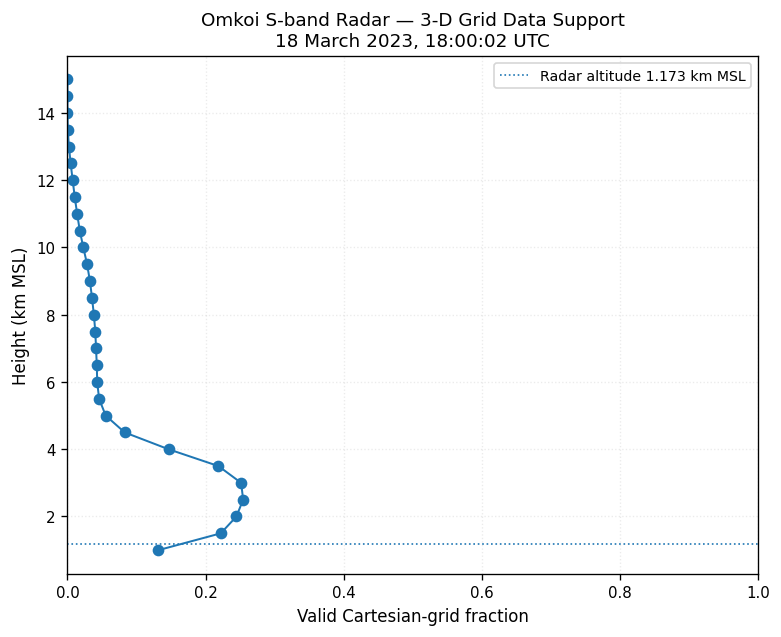

In [22]:
# CELL 22 — Figure: valid fraction versus height

fig = plt.figure(
    figsize=(6.4, 5.2)
)

ax = fig.add_subplot(111)

ax.plot(
    vertical_support[
        "valid_fraction"
    ],
    vertical_support[
        "height_km_MSL"
    ],
    marker="o",
)

ax.axhline(
    radar_alt_msl_m / 1000.0,
    linestyle=":",
    linewidth=1.0,
    label=(
        f"Radar altitude "
        f"{radar_alt_msl_m / 1000:.3f} km MSL"
    ),
)

ax.set_xlabel(
    "Valid Cartesian-grid fraction"
)

ax.set_ylabel(
    "Height (km MSL)"
)

ax.set_xlim(0, 1)

ax.set_title(
    (
        f"{site_name} S-band Radar — "
        "3-D Grid Data Support\n"
        f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')}"
    )
)

ax.grid(
    alpha=0.25,
    linestyle=":",
)

ax.legend()

VALID_FRACTION_FIG = (
    FIGURE_DIR
    / "03_fig01_valid_fraction_vs_height.png"
)

save_figure(
    fig,
    VALID_FRACTION_FIG,
    source_file=selected_filename,
    field=FIELD_Z,
    time_utc=utc_time,
    processing=(
        "Fraction of finite unmasked Cartesian "
        "reflectivity pixels at each MSL level."
    ),
)

plt.show()

# 18. CAPPI — Constant Altitude Plan Position Indicator

```text
PPI
= constant antenna elevation
= beam height changes with range

CAPPI
= constant Cartesian altitude
= interpolated from multiple elevations
```

Therefore:

\[
PPI
eq CAPPI
\]

and:

\[
CAPPI
eq direct\ observation\ everywhere
\]

In [23]:
# CELL 23 — CAPPI extractor

def extract_cappi(
    grid_object,
    field_name,
    target_height_msl_km,
):
    z_km = (
        np.asarray(
            grid_object.z[
                "data"
            ],
            dtype=float,
        )
        / 1000.0
    )

    index = int(
        np.argmin(
            np.abs(
                z_km
                - target_height_msl_km
            )
        )
    )

    actual = float(
        z_km[index]
    )

    data = np.ma.asarray(
        grid_object.fields[
            field_name
        ]["data"][index]
    )

    return {
        "requested_height_km_MSL": float(
            target_height_msl_km
        ),
        "actual_height_km_MSL": actual,
        "height_error_km": float(
            actual
            - target_height_msl_km
        ),
        "level_index": index,
        "data": data,
    }

In [24]:
# CELL 24 — CAPPI-level summary table

cappi_rows = []

for target in (
    CAPPI_LEVELS_MSL_KM
):
    result = extract_cappi(
        grid,
        FIELD_Z,
        target,
    )

    data = result["data"]

    valid = (
        ~np.ma.getmaskarray(data)
        & np.isfinite(
            data.filled(
                np.nan
            )
        )
    )

    values = data.compressed()
    values = values[
        np.isfinite(values)
    ]

    cappi_rows.append({
        "requested_height_km_MSL": (
            result[
                "requested_height_km_MSL"
            ]
        ),
        "actual_height_km_MSL": (
            result[
                "actual_height_km_MSL"
            ]
        ),
        "height_error_km": (
            result[
                "height_error_km"
            ]
        ),
        "level_index": (
            result["level_index"]
        ),
        "valid_fraction": float(
            valid.mean()
        ),
        "max_corrected_ZH_dBZ": (
            float(
                np.nanmax(values)
            )
            if values.size
            else np.nan
        ),
        "P95_corrected_ZH_dBZ": (
            float(
                np.nanpercentile(
                    values,
                    95,
                )
            )
            if values.size
            else np.nan
        ),
    })

cappi_level_table = pd.DataFrame(
    cappi_rows
)

display(cappi_level_table)

CAPPI_LEVEL_CSV = (
    OUTPUT_CSV_DIR
    / "03_CAPPI_level_summary.csv"
)

cappi_level_table.to_csv(
    CAPPI_LEVEL_CSV,
    index=False,
)

,requested_height_km_MSL,actual_height_km_MSL,height_error_km,level_index,valid_fraction,max_corrected_ZH_dBZ,P95_corrected_ZH_dBZ
0,2.0,2.0,0.0,2,0.244625,48.386703,13.210994
1,3.0,3.0,0.0,4,0.251491,48.058693,13.958067
2,4.0,4.0,0.0,6,0.146349,47.976330,17.014222
3,5.0,5.0,0.0,8,0.055373,45.600956,21.647840
4,6.0,6.0,0.0,10,0.043066,36.971405,21.420717
5,8.0,8.0,0.0,14,0.038252,30.349466,19.241482
6,10.0,10.0,0.0,18,0.022960,21.281792,17.468411
7,12.0,12.0,0.0,22,0.007556,21.545567,17.600361


# 19. Prepare GIS domain for CAPPI maps

In [25]:
# CELL 25 — Clip boundaries to grid domain

primary_result = extract_cappi(
    grid,
    FIELD_Z,
    PRIMARY_CAPPI_MSL_KM,
)

primary_level = (
    primary_result[
        "level_index"
    ]
)

grid_lon, grid_lat = (
    grid.get_point_longitude_latitude(
        level=primary_level
    )
)

lon_min = float(
    np.nanmin(grid_lon)
)

lon_max = float(
    np.nanmax(grid_lon)
)

lat_min = float(
    np.nanmin(grid_lat)
)

lat_max = float(
    np.nanmax(grid_lat)
)

adm1_clip = adm1.cx[
    lon_min:lon_max,
    lat_min:lat_max
].copy()

adm2_clip = adm2.cx[
    lon_min:lon_max,
    lat_min:lat_max
].copy()

print(
    "ADM1 in domain:",
    len(adm1_clip),
)

print(
    "ADM2 in domain:",
    len(adm2_clip),
)

ADM1 in domain: 15
ADM2 in domain: 124


In [26]:
# CELL 26 — Geographic CAPPI plotting helper

def plot_geographic_cappi(
    grid_object,
    *,
    level_index,
    data,
    height_msl_km,
    output_path,
    show_adm2=True,
):
    lon, lat = (
        grid_object.get_point_longitude_latitude(
            level=level_index
        )
    )

    projection = ccrs.PlateCarree()

    fig = plt.figure(
        figsize=(8.2, 7.4)
    )

    ax = plt.axes(
        projection=projection
    )

    ax.set_extent(
        [
            float(np.nanmin(lon)),
            float(np.nanmax(lon)),
            float(np.nanmin(lat)),
            float(np.nanmax(lat)),
        ],
        crs=projection,
    )

    mesh = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=projection,
        shading="auto",
        cmap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        rasterized=True,
        zorder=1,
    )

    if show_adm2:
        for geom in (
            adm2_clip.geometry
        ):
            ax.add_geometries(
                [geom],
                crs=projection,
                facecolor="none",
                edgecolor="0.70",
                linewidth=0.20,
                zorder=2,
            )

    for geom in adm1_clip.geometry:
        ax.add_geometries(
            [geom],
            crs=projection,
            facecolor="none",
            edgecolor="0.22",
            linewidth=0.55,
            zorder=3,
        )

    ax.scatter(
        radar_lon,
        radar_lat,
        transform=projection,
        marker="^",
        s=38,
        zorder=4,
    )

    gridliner = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.40,
        alpha=0.30,
        linestyle=":",
    )

    gridliner.top_labels = False
    gridliner.right_labels = False
    gridliner.xlabel_style = {
        "size": 9
    }
    gridliner.ylabel_style = {
        "size": 9
    }

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.88,
    )

    cbar.set_label(
        "Corrected reflectivity (dBZ)"
    )

    ax.set_title(
        (
            f"{site_name} S-band Radar — "
            f"CAPPI {height_msl_km:.1f} km MSL\n"
            f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')}"
        ),
        pad=10,
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        field=FIELD_Z,
        height_msl_km=height_msl_km,
        time_utc=utc_time,
        processing=(
            "CAPPI extracted from 3-D Py-ART grid; "
            "Barnes2; dist_beam ROI; MSL vertical reference."
        ),
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        cmap=CMAP_Z,
    )

    plt.show()

In [27]:
# CELL 27 — CAPPI support plotting helper

def plot_cappi_support(
    grid_object,
    *,
    level_index,
    data,
    height_msl_km,
    output_path,
):
    lon, lat = (
        grid_object.get_point_longitude_latitude(
            level=level_index
        )
    )

    valid = (
        ~np.ma.getmaskarray(data)
        & np.isfinite(
            data.filled(
                np.nan
            )
        )
    ).astype(float)

    projection = ccrs.PlateCarree()

    fig = plt.figure(
        figsize=(8.0, 7.2)
    )

    ax = plt.axes(
        projection=projection
    )

    ax.set_extent(
        [
            float(np.nanmin(lon)),
            float(np.nanmax(lon)),
            float(np.nanmin(lat)),
            float(np.nanmax(lat)),
        ],
        crs=projection,
    )

    mesh = ax.pcolormesh(
        lon,
        lat,
        valid,
        transform=projection,
        shading="auto",
        cmap="Greys",
        vmin=0,
        vmax=1,
        rasterized=True,
        zorder=1,
    )

    for geom in adm1_clip.geometry:
        ax.add_geometries(
            [geom],
            crs=projection,
            facecolor="none",
            edgecolor="0.25",
            linewidth=0.50,
            zorder=2,
        )

    ax.scatter(
        radar_lon,
        radar_lat,
        transform=projection,
        marker="^",
        s=35,
        zorder=3,
    )

    gridliner = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.4,
        alpha=0.3,
        linestyle=":",
    )

    gridliner.top_labels = False
    gridliner.right_labels = False

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.88,
        ticks=[0, 1],
    )

    cbar.set_label(
        "Cartesian data support"
    )

    ax.set_title(
        (
            f"{site_name} — CAPPI Data Support\n"
            f"{height_msl_km:.1f} km MSL | "
            f"{utc_time.strftime('%d %B %Y, %H:%M:%S UTC')}"
        )
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        field="valid_data_support",
        height_msl_km=height_msl_km,
        time_utc=utc_time,
        processing=(
            "Binary support mask from gridded corrected reflectivity."
        ),
        vmin=0,
        vmax=1,
        cmap="Greys",
    )

    plt.show()

# 20. Export publication-ready CAPPI levels

Individual figures are exported so they can later be combined according to the target journal layout without re-running the radar analysis.

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_ZH_02.0kmMSL_20230318_180002UTC.png


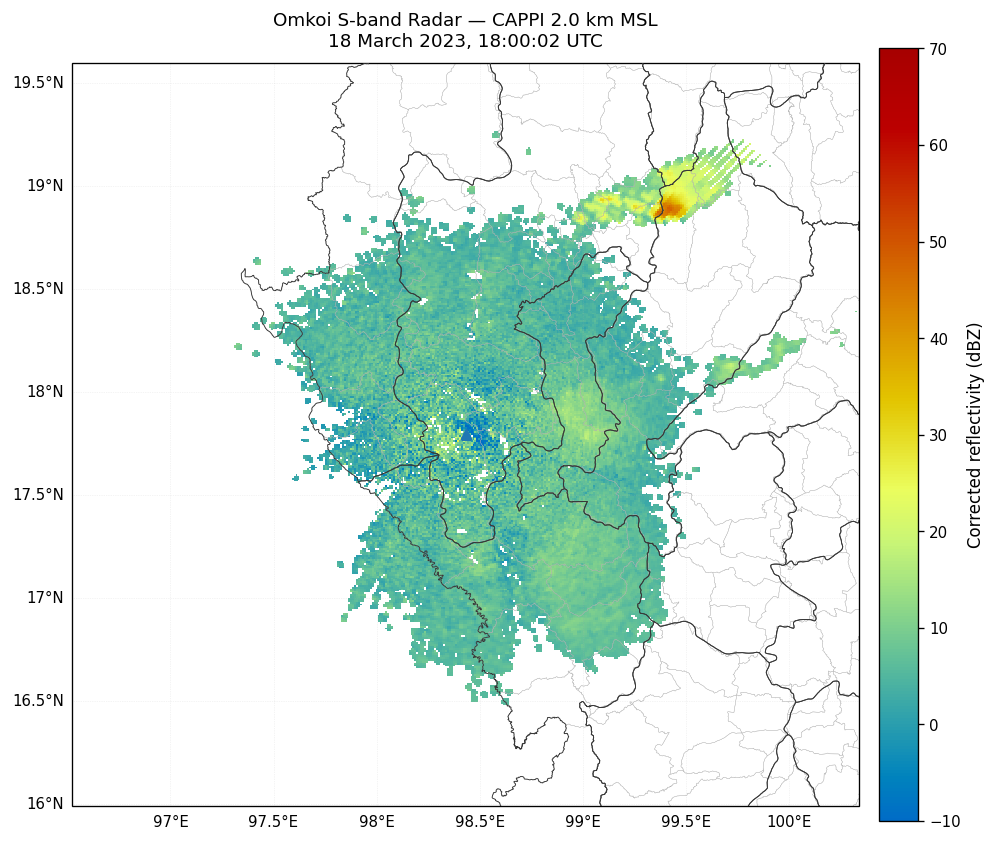

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_ZH_03.0kmMSL_20230318_180002UTC.png


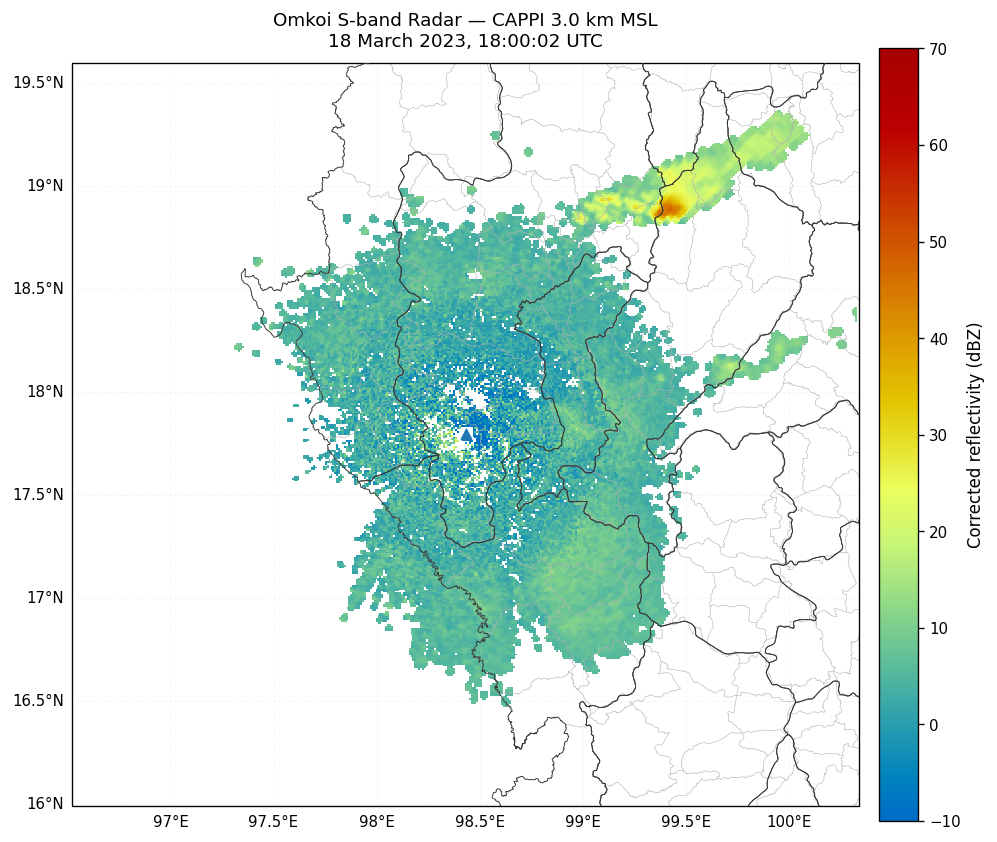

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_ZH_04.0kmMSL_20230318_180002UTC.png


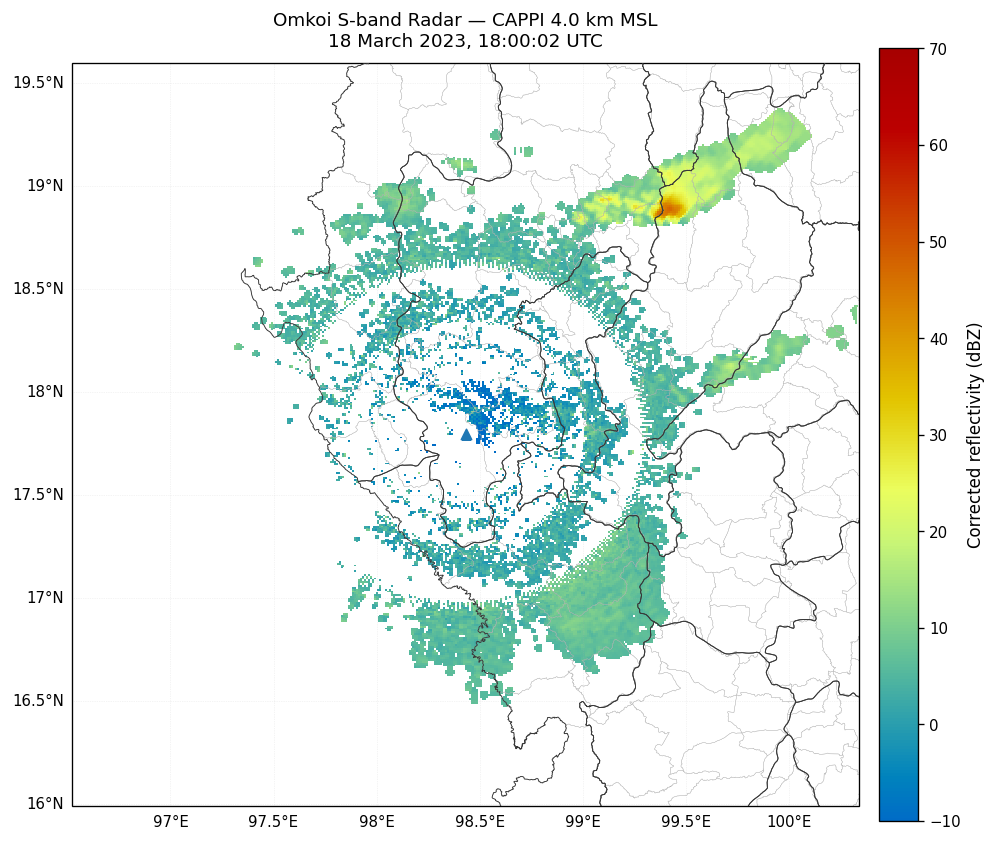

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_ZH_05.0kmMSL_20230318_180002UTC.png


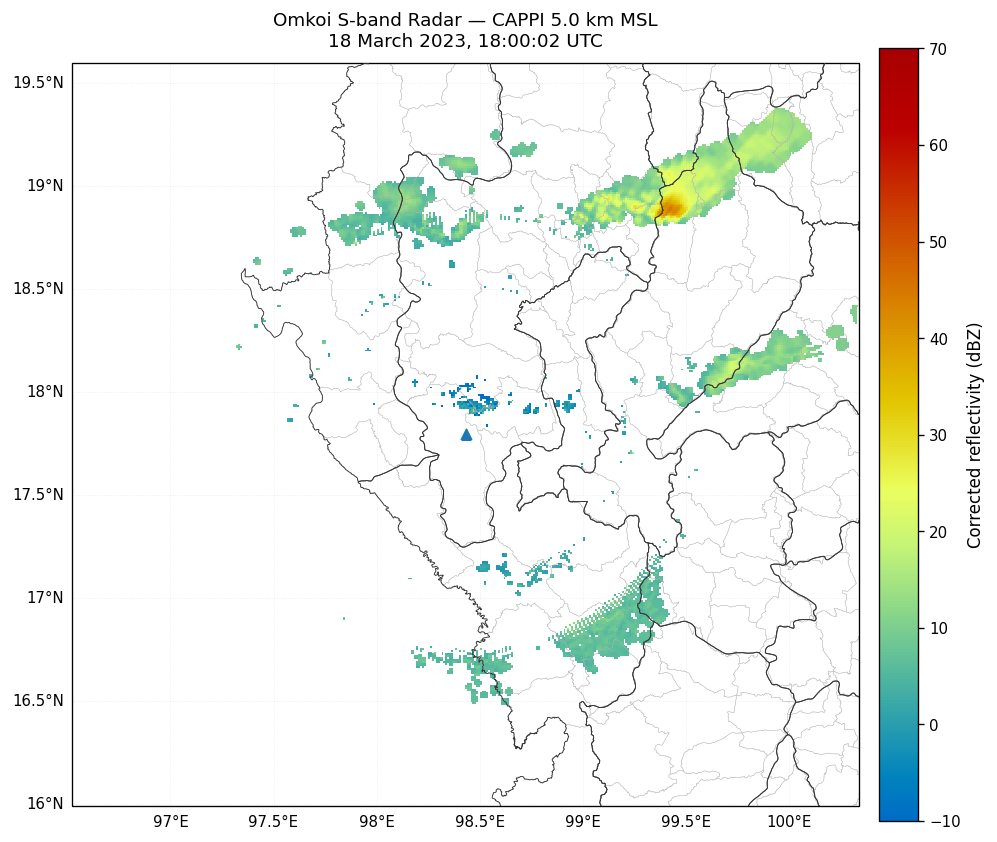

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_ZH_06.0kmMSL_20230318_180002UTC.png


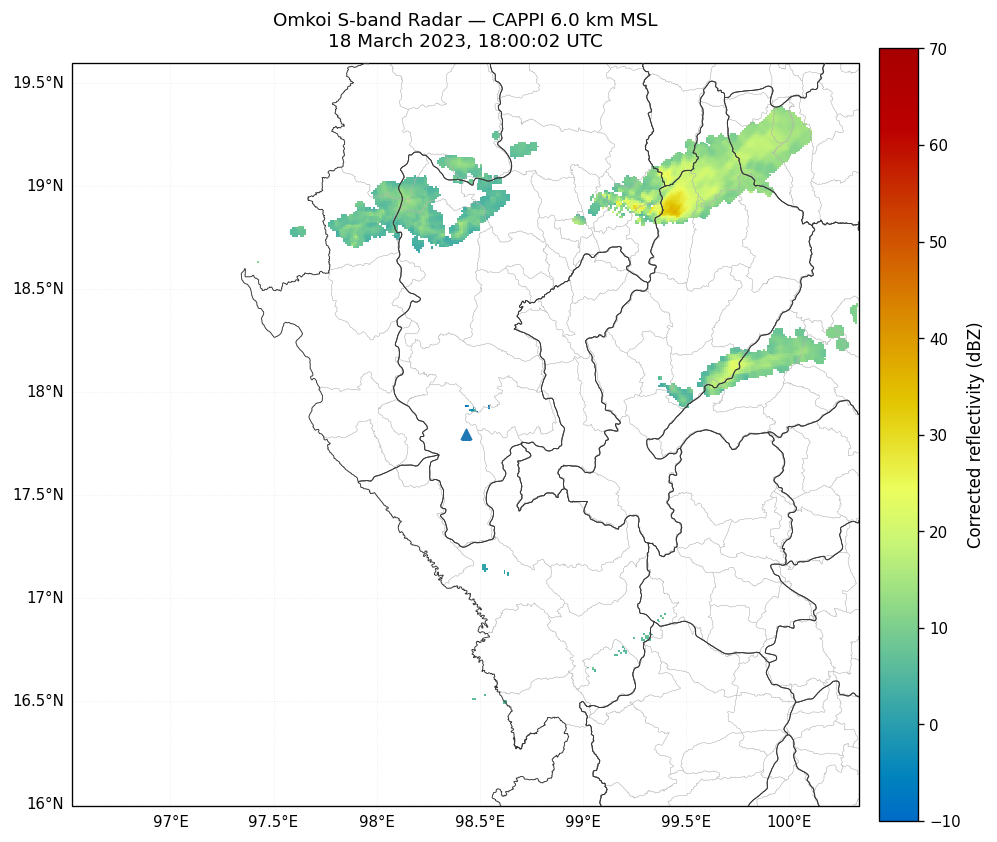

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_ZH_08.0kmMSL_20230318_180002UTC.png


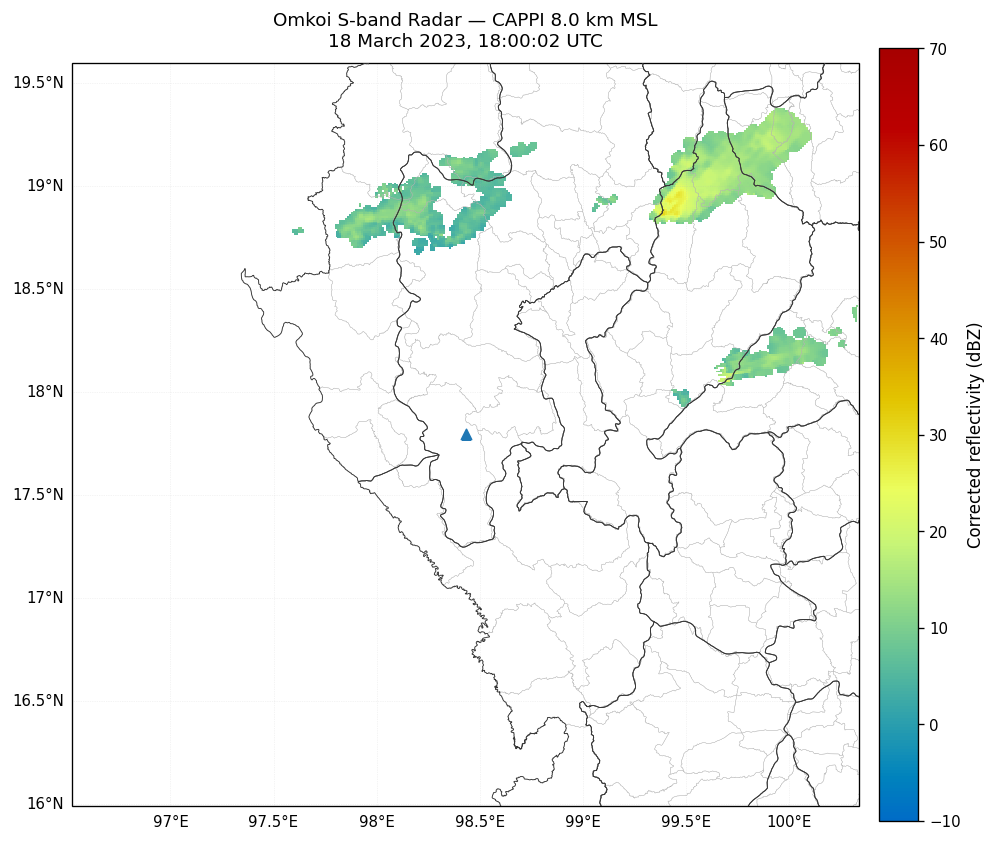

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_ZH_10.0kmMSL_20230318_180002UTC.png


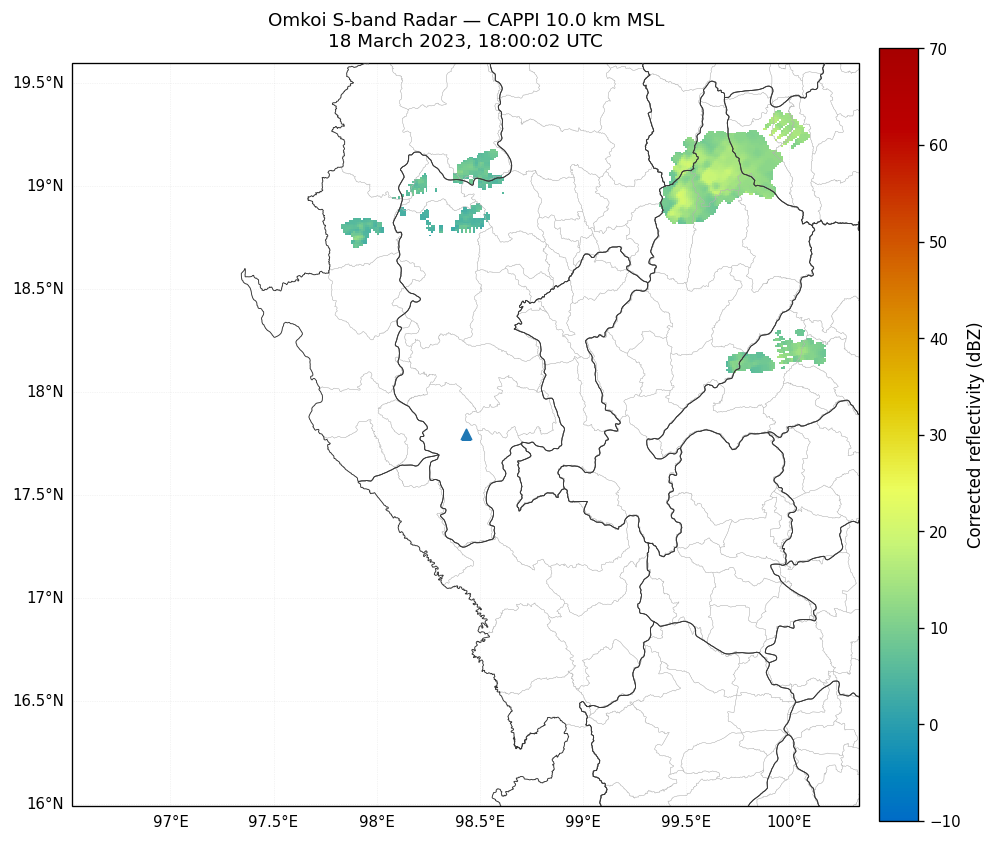

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_ZH_12.0kmMSL_20230318_180002UTC.png


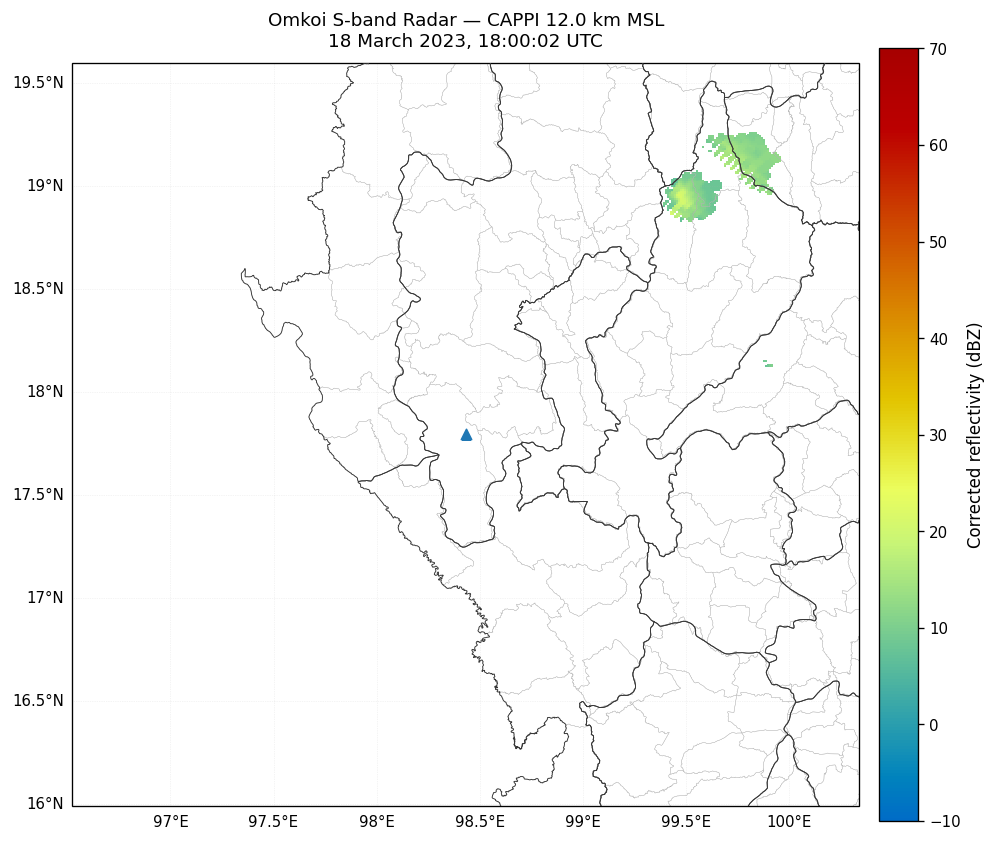

In [28]:
# CELL 28 — CAPPI figures

CAPPI_PRODUCTS = {}

for target in (
    CAPPI_LEVELS_MSL_KM
):
    result = extract_cappi(
        grid,
        FIELD_Z,
        target,
    )

    actual = result[
        "actual_height_km_MSL"
    ]

    output_path = (
        FIGURE_DIR
        / (
            "03_CAPPI_ZH_"
            f"{actual:04.1f}kmMSL_"
            f"{utc_time.strftime('%Y%m%d_%H%M%S')}UTC.png"
        )
    )

    plot_geographic_cappi(
        grid,
        level_index=(
            result["level_index"]
        ),
        data=result["data"],
        height_msl_km=actual,
        output_path=output_path,
        show_adm2=True,
    )

    CAPPI_PRODUCTS[target] = {
        "level_index": (
            result["level_index"]
        ),
        "actual_height_km_MSL": actual,
        "figure": str(output_path),
    }

# 21. Selected data-support maps

Coverage maps are generated at 2, 6, 10 and 12 km MSL.

A blank CAPPI pixel must not automatically be interpreted as 0 dBZ.

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_support_02.0kmMSL.png


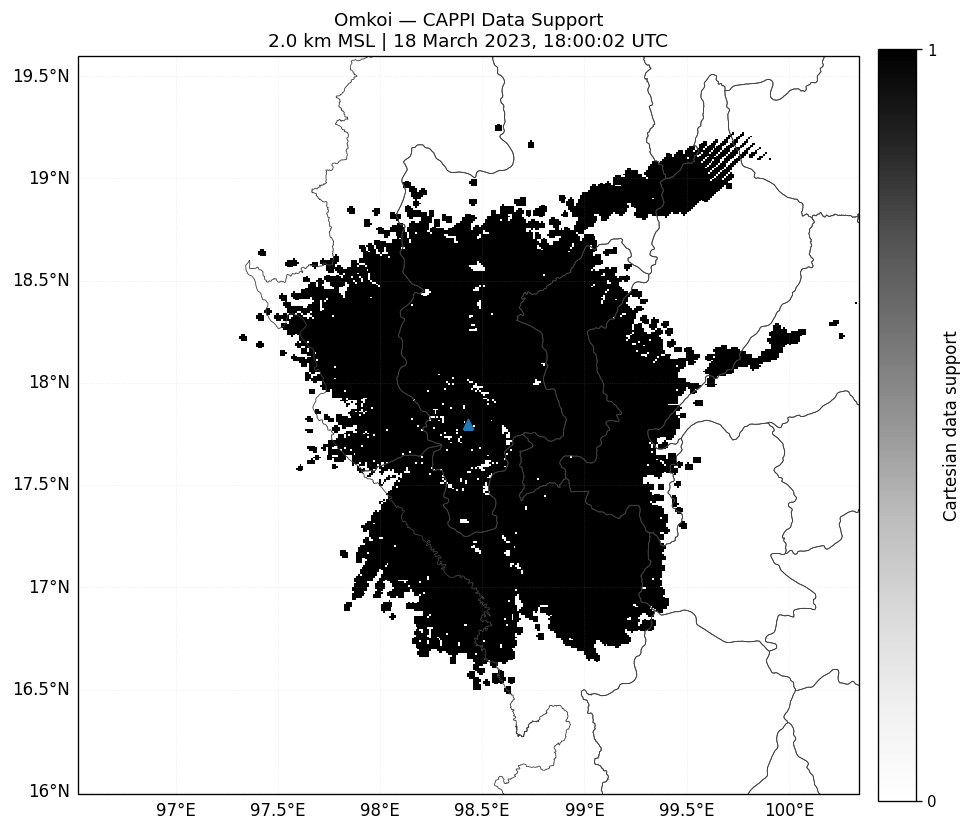

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_support_06.0kmMSL.png


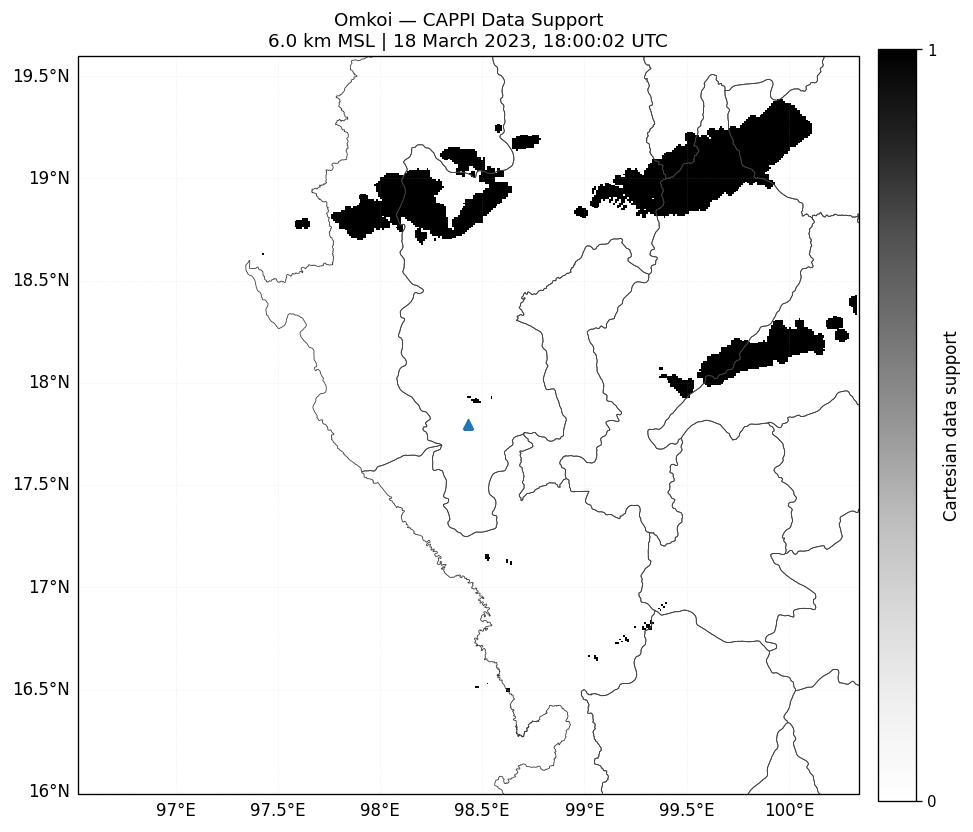

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_support_10.0kmMSL.png


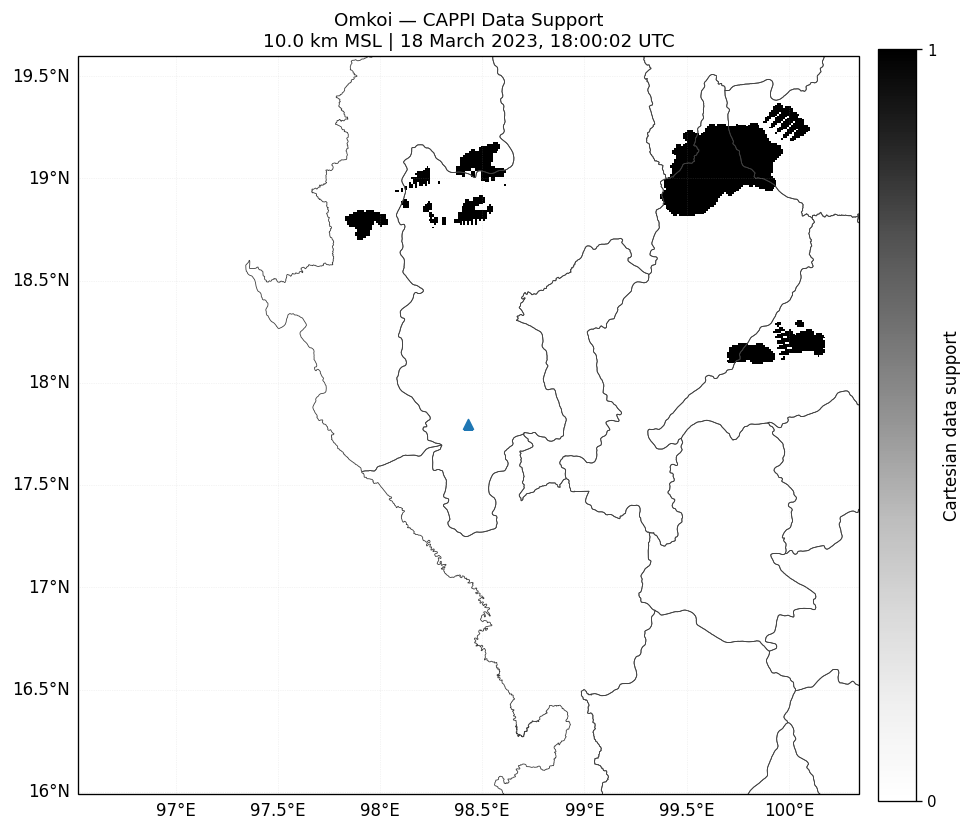

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_CAPPI_support_12.0kmMSL.png


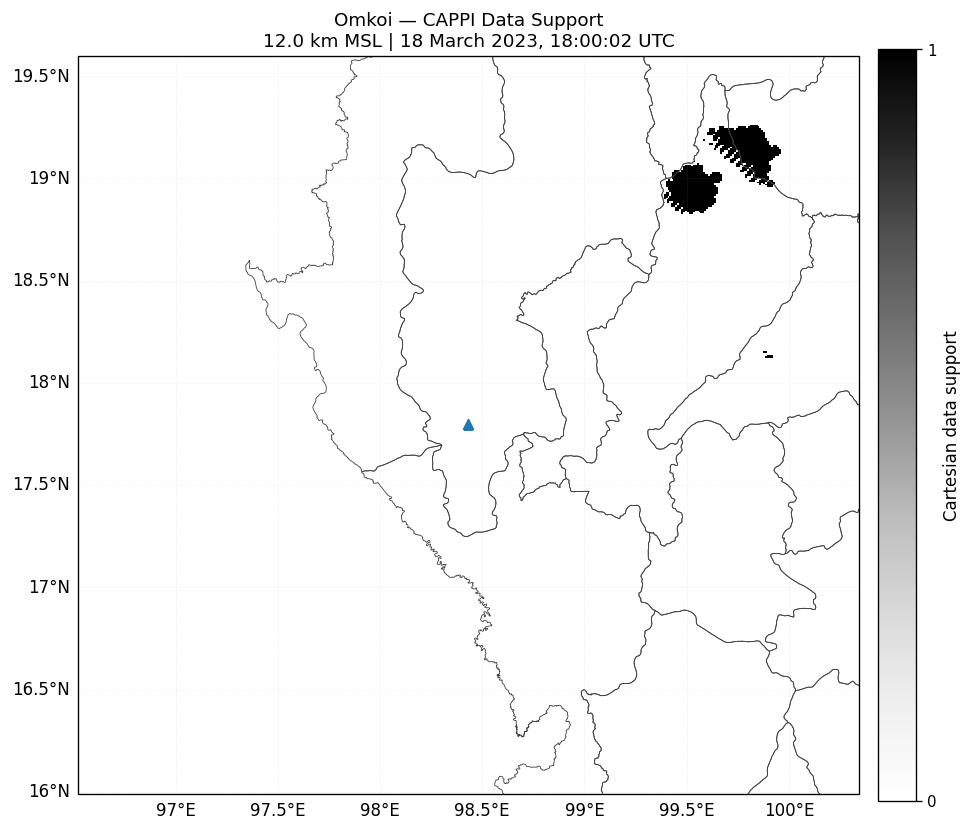

In [29]:
# CELL 29 — CAPPI support maps

for target in [
    2.0,
    6.0,
    10.0,
    12.0,
]:
    result = extract_cappi(
        grid,
        FIELD_Z,
        target,
    )

    output_path = (
        FIGURE_DIR
        / (
            "03_CAPPI_support_"
            f"{result['actual_height_km_MSL']:04.1f}kmMSL.png"
        )
    )

    plot_cappi_support(
        grid,
        level_index=(
            result["level_index"]
        ),
        data=result["data"],
        height_msl_km=(
            result[
                "actual_height_km_MSL"
            ]
        ),
        output_path=output_path,
    )

## RESEARCH NOTE — CAPPI support

Missing support can arise from scan geometry, masked gates or insufficient nearby observations.

This matters directly for later:

- echo top
- VIL
- storm volume
- MESH

# 22. EXPERIMENT — Radius-of-Influence sensitivity

To isolate ROI effects efficiently, use:

- one 4-km-MSL level
- ±80-km domain
- 1-km grid spacing
- constant ROI = 0.5, 1.0 and 2.0 km

In [30]:
# CELL 30 — Single-level sensitivity helper

def make_single_level_grid(
    *,
    target_height_msl_km,
    half_width_km,
    spacing_km,
    roi_func,
    constant_roi_m=None,
):
    nxy = count_points(
        -half_width_km,
        half_width_km,
        spacing_km,
    )

    z_m = (
        target_height_msl_km
        * 1000.0
    )

    shape = (
        1,
        nxy,
        nxy,
    )

    limits = (
        (z_m, z_m),
        (
            -half_width_km * 1000.0,
            half_width_km * 1000.0,
        ),
        (
            -half_width_km * 1000.0,
            half_width_km * 1000.0,
        ),
    )

    return build_cartesian_grid(
        radar,
        grid_shape=shape,
        grid_limits=limits,
        field_name=FIELD_Z,
        gatefilter=grid_gatefilter,
        weighting_function=(
            WEIGHTING_FUNCTION
        ),
        roi_func=roi_func,
        min_radius_m=MIN_RADIUS_M,
        constant_roi_m=constant_roi_m,
        map_roi=False,
    )

In [31]:
# CELL 31 — ROI sensitivity table

roi_rows = []
roi_grids = {}

for roi_m in ROI_CONSTANTS_M:
    start = time.perf_counter()

    grid_roi = make_single_level_grid(
        target_height_msl_km=(
            EXPERIMENT_CAPPI_MSL_KM
        ),
        half_width_km=(
            SENSITIVITY_HALF_WIDTH_KM
        ),
        spacing_km=1.0,
        roi_func="constant",
        constant_roi_m=roi_m,
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    data = np.ma.asarray(
        grid_roi.fields[
            FIELD_Z
        ]["data"][0]
    )

    valid = (
        ~np.ma.getmaskarray(data)
        & np.isfinite(
            data.filled(
                np.nan
            )
        )
    )

    values = data.compressed()
    values = values[
        np.isfinite(values)
    ]

    roi_rows.append({
        "constant_ROI_m": roi_m,
        "height_km_MSL": (
            EXPERIMENT_CAPPI_MSL_KM
        ),
        "grid_spacing_km": 1.0,
        "valid_fraction": float(
            valid.mean()
        ),
        "max_ZH_dBZ": (
            float(
                np.nanmax(values)
            )
            if values.size
            else np.nan
        ),
        "P95_ZH_dBZ": (
            float(
                np.nanpercentile(
                    values,
                    95,
                )
            )
            if values.size
            else np.nan
        ),
        "elapsed_seconds": elapsed,
    })

    roi_grids[roi_m] = grid_roi

roi_experiment = pd.DataFrame(
    roi_rows
)

display(roi_experiment)

ROI_EXPERIMENT_CSV = (
    OUTPUT_CSV_DIR
    / "03_ROI_sensitivity.csv"
)

roi_experiment.to_csv(
    ROI_EXPERIMENT_CSV,
    index=False,
)

,constant_ROI_m,height_km_MSL,grid_spacing_km,valid_fraction,max_ZH_dBZ,P95_ZH_dBZ,elapsed_seconds
0,500.0,4.0,1.0,0.043363,13.0,6.50000,0.668887
1,1000.0,4.0,1.0,0.302419,17.5,7.50000,0.515774
2,2000.0,4.0,1.0,0.902087,17.5,8.27474,0.545231


Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_ROI_sensitivity_0500m.png


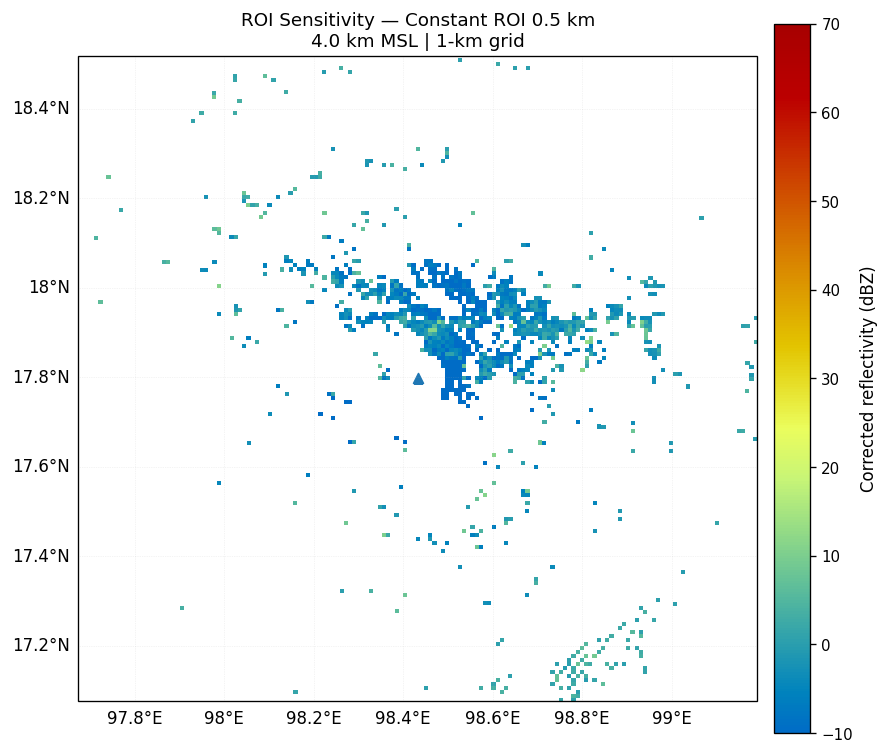

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_ROI_sensitivity_1000m.png


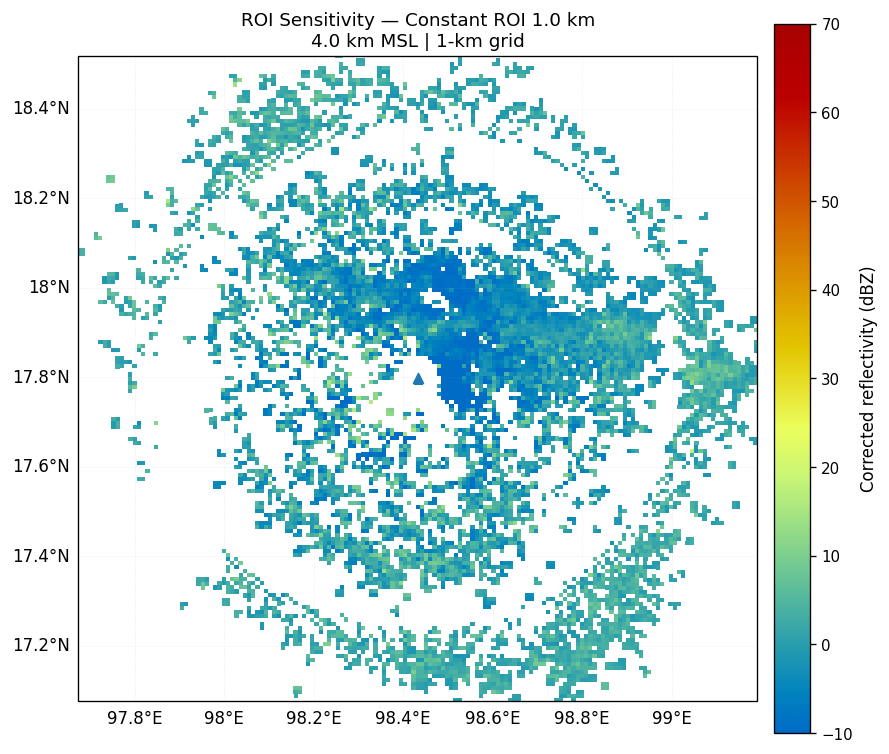

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_ROI_sensitivity_2000m.png


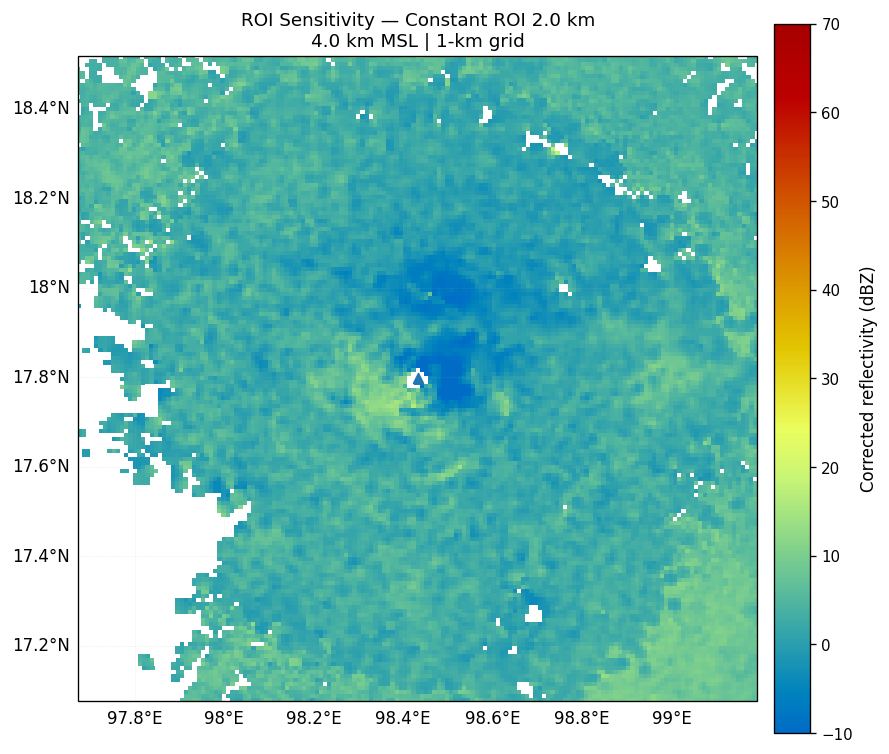

In [32]:
# CELL 32 — ROI sensitivity figures

for roi_m, grid_roi in (
    roi_grids.items()
):
    data = np.ma.asarray(
        grid_roi.fields[
            FIELD_Z
        ]["data"][0]
    )

    lon, lat = (
        grid_roi.get_point_longitude_latitude(
            level=0
        )
    )

    projection = ccrs.PlateCarree()

    fig = plt.figure(
        figsize=(7.3, 6.8)
    )

    ax = plt.axes(
        projection=projection
    )

    ax.set_extent(
        [
            float(np.nanmin(lon)),
            float(np.nanmax(lon)),
            float(np.nanmin(lat)),
            float(np.nanmax(lat)),
        ],
        crs=projection,
    )

    mesh = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=projection,
        shading="auto",
        cmap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.88,
    )

    cbar.set_label(
        "Corrected reflectivity (dBZ)"
    )

    ax.scatter(
        radar_lon,
        radar_lat,
        transform=projection,
        marker="^",
        s=35,
    )

    gridliner = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.4,
        alpha=0.3,
        linestyle=":",
    )

    gridliner.top_labels = False
    gridliner.right_labels = False

    ax.set_title(
        (
            "ROI Sensitivity — "
            f"Constant ROI {roi_m / 1000:.1f} km\n"
            f"{EXPERIMENT_CAPPI_MSL_KM:.1f} km MSL | "
            "1-km grid"
        )
    )

    output_path = (
        FIGURE_DIR
        / (
            "03_ROI_sensitivity_"
            f"{int(roi_m):04d}m.png"
        )
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        field=FIELD_Z,
        height_msl_km=(
            EXPERIMENT_CAPPI_MSL_KM
        ),
        time_utc=utc_time,
        processing=(
            f"Constant ROI={roi_m:.0f} m; "
            "Barnes2; single-level sensitivity grid."
        ),
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        cmap=CMAP_Z,
    )

    plt.show()

# 23. EXPERIMENT — Cartesian grid-spacing sensitivity

Compare:

```text
2.0 km
1.0 km
0.5 km
```

using the same ±80-km domain and 4-km-MSL level.

The purpose is to demonstrate that finer Cartesian spacing does not generate new radar observations.

In [33]:
# CELL 33 — Grid-spacing sensitivity table

spacing_rows = []
spacing_grids = {}

for spacing_km in (
    GRID_SPACING_EXPERIMENT_KM
):
    start = time.perf_counter()

    grid_spacing = (
        make_single_level_grid(
            target_height_msl_km=(
                EXPERIMENT_CAPPI_MSL_KM
            ),
            half_width_km=(
                SENSITIVITY_HALF_WIDTH_KM
            ),
            spacing_km=spacing_km,
            roi_func=ROI_FUNCTION,
        )
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    data = np.ma.asarray(
        grid_spacing.fields[
            FIELD_Z
        ]["data"][0]
    )

    valid = (
        ~np.ma.getmaskarray(data)
        & np.isfinite(
            data.filled(
                np.nan
            )
        )
    )

    values = data.compressed()
    values = values[
        np.isfinite(values)
    ]

    spacing_rows.append({
        "grid_spacing_km": spacing_km,
        "grid_shape_y_x": (
            f"{data.shape[0]}x"
            f"{data.shape[1]}"
        ),
        "height_km_MSL": (
            EXPERIMENT_CAPPI_MSL_KM
        ),
        "valid_fraction": float(
            valid.mean()
        ),
        "max_ZH_dBZ": (
            float(
                np.nanmax(values)
            )
            if values.size
            else np.nan
        ),
        "P95_ZH_dBZ": (
            float(
                np.nanpercentile(
                    values,
                    95,
                )
            )
            if values.size
            else np.nan
        ),
        "elapsed_seconds": elapsed,
    })

    spacing_grids[
        spacing_km
    ] = grid_spacing

spacing_experiment = pd.DataFrame(
    spacing_rows
)

display(spacing_experiment)

SPACING_EXPERIMENT_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_spacing_sensitivity.csv"
)

spacing_experiment.to_csv(
    SPACING_EXPERIMENT_CSV,
    index=False,
)

,grid_spacing_km,grid_shape_y_x,height_km_MSL,valid_fraction,max_ZH_dBZ,P95_ZH_dBZ,elapsed_seconds
0,2.0,81x81,4.0,0.294010,13.500000,8.700030,0.515113
1,1.0,161x161,4.0,0.296516,17.500000,8.647689,0.604758
2,0.5,321x321,4.0,0.296649,19.021696,8.647523,0.800816


Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_grid_spacing_2.0km.png


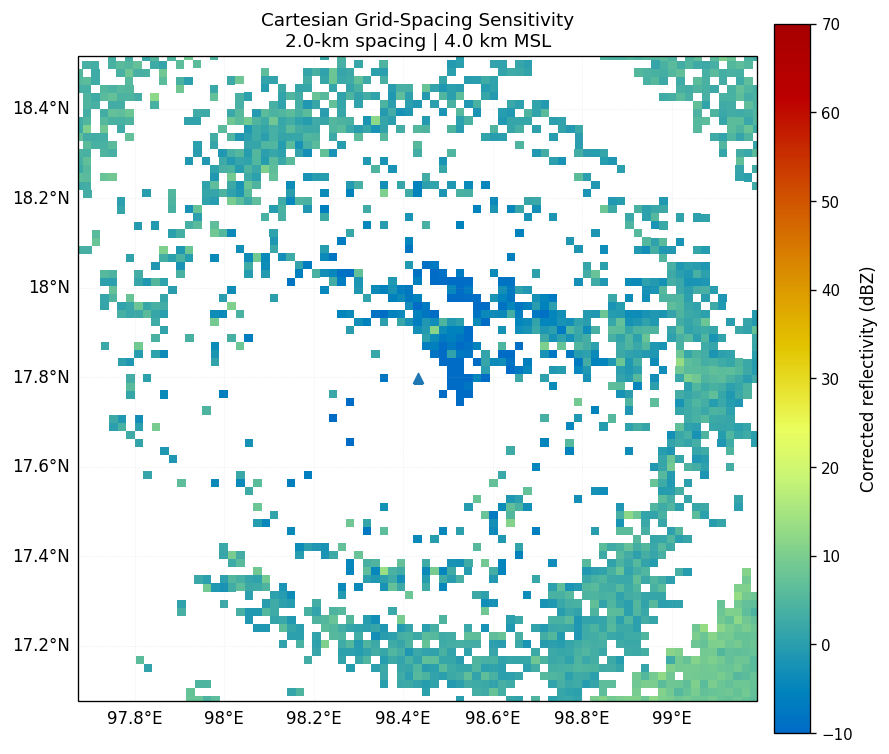

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_grid_spacing_1.0km.png


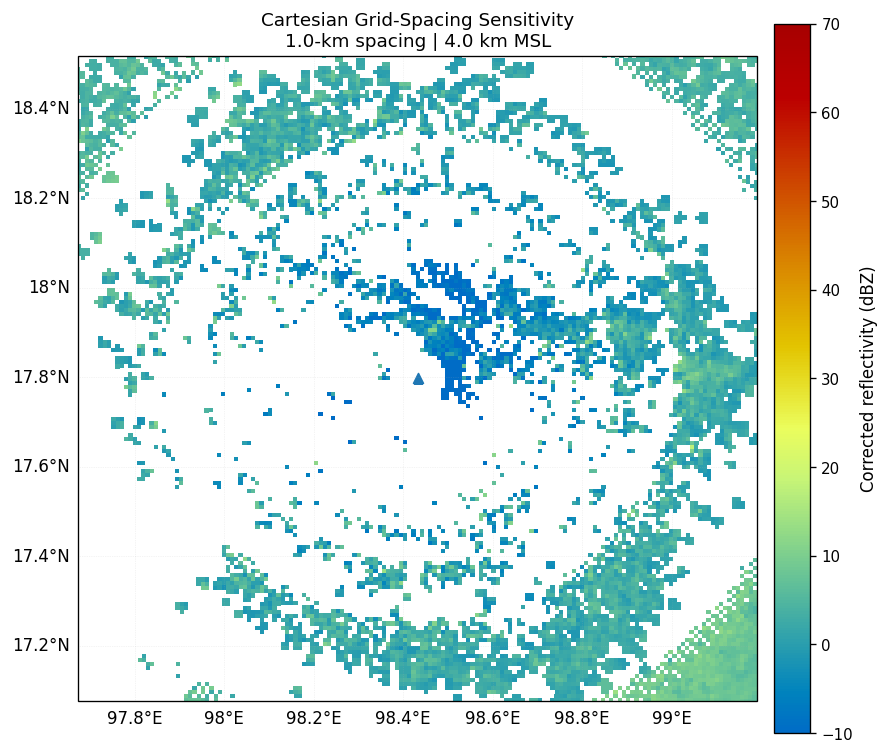

Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_grid_spacing_0.5km.png


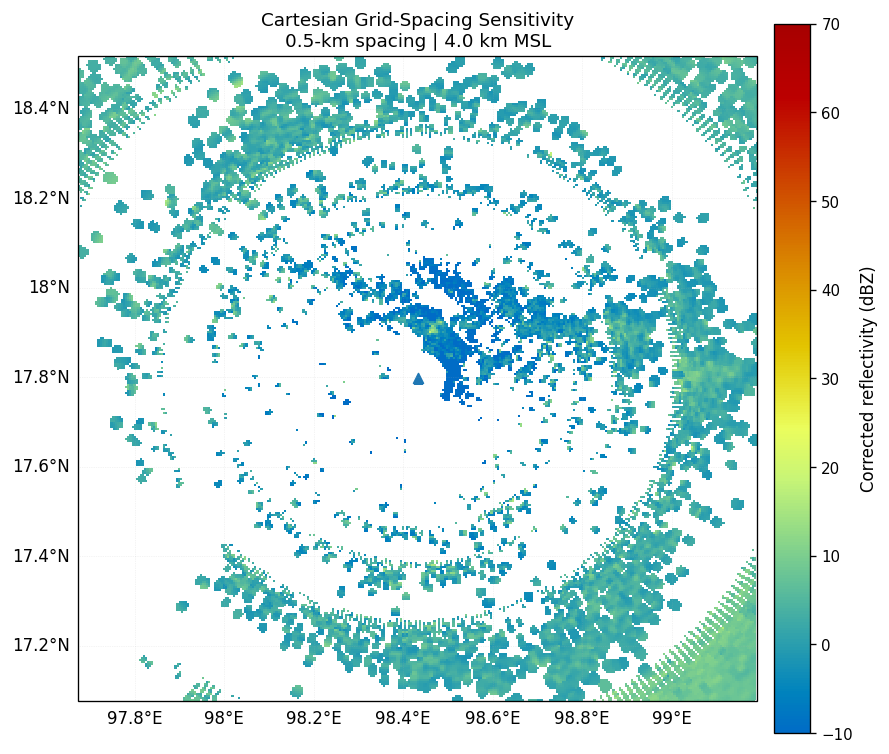

In [34]:
# CELL 34 — Grid-spacing figures

for spacing_km, grid_spacing in (
    spacing_grids.items()
):
    data = np.ma.asarray(
        grid_spacing.fields[
            FIELD_Z
        ]["data"][0]
    )

    lon, lat = (
        grid_spacing.get_point_longitude_latitude(
            level=0
        )
    )

    projection = ccrs.PlateCarree()

    fig = plt.figure(
        figsize=(7.3, 6.8)
    )

    ax = plt.axes(
        projection=projection
    )

    ax.set_extent(
        [
            float(np.nanmin(lon)),
            float(np.nanmax(lon)),
            float(np.nanmin(lat)),
            float(np.nanmax(lat)),
        ],
        crs=projection,
    )

    mesh = ax.pcolormesh(
        lon,
        lat,
        data,
        transform=projection,
        shading="auto",
        cmap=CMAP_Z,
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        rasterized=True,
    )

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.88,
    )

    cbar.set_label(
        "Corrected reflectivity (dBZ)"
    )

    ax.scatter(
        radar_lon,
        radar_lat,
        transform=projection,
        marker="^",
        s=35,
    )

    gridliner = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.4,
        alpha=0.3,
        linestyle=":",
    )

    gridliner.top_labels = False
    gridliner.right_labels = False

    ax.set_title(
        (
            "Cartesian Grid-Spacing Sensitivity\n"
            f"{spacing_km:.1f}-km spacing | "
            f"{EXPERIMENT_CAPPI_MSL_KM:.1f} km MSL"
        )
    )

    output_path = (
        FIGURE_DIR
        / (
            "03_grid_spacing_"
            f"{spacing_km:.1f}km.png"
        )
    )

    save_figure(
        fig,
        output_path,
        source_file=selected_filename,
        field=FIELD_Z,
        height_msl_km=(
            EXPERIMENT_CAPPI_MSL_KM
        ),
        time_utc=utc_time,
        processing=(
            f"Spacing={spacing_km:.1f} km; "
            "Barnes2 + dist_beam."
        ),
        vmin=ZH_VMIN,
        vmax=ZH_VMAX,
        cmap=CMAP_Z,
    )

    plt.show()

# 24. CRS: radar Cartesian, geographic and UTM

Three coordinate representations are used:

```text
Radar Cartesian
x / y in metres relative to radar-centered origin

Geographic
longitude / latitude, EPSG:4326

Projected
WGS84 / UTM, metres
```

Py-ART's native `pyart_aeqd` projection is radar-centered azimuthal equidistant.

In [35]:
# CELL 35 — Inspect grid projection

projection_metadata = {
    "grid_projparams": str(
        grid.get_projparams()
    ),
    "origin_latitude_deg": float(
        grid.origin_latitude[
            "data"
        ][0]
    ),
    "origin_longitude_deg": float(
        grid.origin_longitude[
            "data"
        ][0]
    ),
    "origin_altitude_m": float(
        grid.origin_altitude[
            "data"
        ][0]
    ),
}

display(
    pd.DataFrame(
        projection_metadata.items(),
        columns=[
            "projection_property",
            "value",
        ],
    )
)

,projection_property,value
0,grid_projparams,"{'proj': 'pyart_aeqd', 'lon_0': np.float64(98...."
1,origin_latitude_deg,17.798207
2,origin_longitude_deg,98.432326
3,origin_altitude_m,0.0


# 25. Derive UTM zone automatically

\[
zone =
\left\lfloor
rac{longitude+180}{6}

ight\rfloor + 1
\]

For Omkoi, the result should be UTM Zone 47N.

The code remains transferable to other radar stations.

In [36]:
# CELL 36 — Automatic UTM CRS

def utm_from_lon_lat(
    lon,
    lat,
):
    zone = int(
        np.floor(
            (lon + 180.0)
            / 6.0
        )
        + 1
    )

    if lat >= 0:
        epsg = 32600 + zone
        hemisphere = "N"
    else:
        epsg = 32700 + zone
        hemisphere = "S"

    return {
        "zone": zone,
        "hemisphere": hemisphere,
        "epsg": epsg,
        "crs": CRS.from_epsg(
            epsg
        ),
    }


UTM_INFO = utm_from_lon_lat(
    radar_lon,
    radar_lat,
)

print(
    "UTM:",
    (
        f"{UTM_INFO['zone']}"
        f"{UTM_INFO['hemisphere']}"
    ),
)

print(
    "EPSG:",
    UTM_INFO["epsg"],
)

UTM: 47N
EPSG: 32647


In [37]:
# CELL 37 — Coordinate round-trip test

to_utm = Transformer.from_crs(
    "EPSG:4326",
    UTM_INFO["crs"],
    always_xy=True,
)

to_wgs84 = Transformer.from_crs(
    UTM_INFO["crs"],
    "EPSG:4326",
    always_xy=True,
)

radar_easting, radar_northing = (
    to_utm.transform(
        radar_lon,
        radar_lat,
    )
)

lon_back, lat_back = (
    to_wgs84.transform(
        radar_easting,
        radar_northing,
    )
)

coordinate_test = pd.DataFrame({
    "quantity": [
        "radar_longitude_deg",
        "radar_latitude_deg",
        "UTM_easting_m",
        "UTM_northing_m",
        "roundtrip_longitude_deg",
        "roundtrip_latitude_deg",
    ],
    "value": [
        radar_lon,
        radar_lat,
        radar_easting,
        radar_northing,
        lon_back,
        lat_back,
    ],
})

display(coordinate_test)

,quantity,value
0,radar_longitude_deg,9.843233e+01
1,radar_latitude_deg,1.779821e+01
2,UTM_easting_m,4.398358e+05
3,UTM_northing_m,1.967951e+06
4,roundtrip_longitude_deg,9.843233e+01
5,roundtrip_latitude_deg,1.779821e+01


# 26. Point extraction from CAPPI

To avoid inventing an arbitrary teaching location, the example uses the strongest valid grid cell at 4 km MSL.

The Notebook then demonstrates reusable extraction from a requested lon/lat.

> **CORE**
>
> CAPPI extraction returns an **interpolated Cartesian value**, not a native radar gate.

In [38]:
# CELL 38 — Strongest 4-km-MSL CAPPI point

point_cappi = extract_cappi(
    grid,
    FIELD_Z,
    EXPERIMENT_CAPPI_MSL_KM,
)

point_array = (
    point_cappi["data"]
    .filled(np.nan)
)

if not np.isfinite(
    point_array
).any():
    raise RuntimeError(
        "No valid CAPPI pixels at 4 km MSL."
    )

flat_index = int(
    np.nanargmax(
        point_array
    )
)

iy, ix = np.unravel_index(
    flat_index,
    point_array.shape,
)

lon_2d, lat_2d = (
    grid.get_point_longitude_latitude(
        level=(
            point_cappi[
                "level_index"
            ]
        )
    )
)

point_lon = float(
    lon_2d[iy, ix]
)

point_lat = float(
    lat_2d[iy, ix]
)

point_e, point_n = (
    to_utm.transform(
        point_lon,
        point_lat,
    )
)

point_example = pd.DataFrame({
    "quantity": [
        "height_km_MSL",
        "grid_x_m",
        "grid_y_m",
        "longitude_deg",
        "latitude_deg",
        "UTM_easting_m",
        "UTM_northing_m",
        "corrected_reflectivity_dBZ",
    ],
    "value": [
        point_cappi[
            "actual_height_km_MSL"
        ],
        float(
            grid.x["data"][ix]
        ),
        float(
            grid.y["data"][iy]
        ),
        point_lon,
        point_lat,
        point_e,
        point_n,
        float(
            point_array[iy, ix]
        ),
    ],
})

display(point_example)

,quantity,value
0,height_km_MSL,4.000000e+00
1,grid_x_m,1.040000e+05
2,grid_y_m,1.220000e+05
3,longitude_deg,9.942082e+01
4,latitude_deg,1.889287e+01
5,UTM_easting_m,5.443202e+05
6,UTM_northing_m,2.089026e+06
7,corrected_reflectivity_dBZ,4.797633e+01


In [39]:
# CELL 39 — Reusable nearest-CAPPI extraction

def extract_nearest_cappi_point(
    grid_object,
    *,
    field_name,
    target_height_msl_km,
    longitude,
    latitude,
):
    cappi = extract_cappi(
        grid_object,
        field_name,
        target_height_msl_km,
    )

    lon, lat = (
        grid_object.get_point_longitude_latitude(
            level=cappi[
                "level_index"
            ]
        )
    )

    distance2 = (
        (lon - longitude)**2
        + (lat - latitude)**2
    )

    flat = int(
        np.nanargmin(
            distance2
        )
    )

    iy, ix = np.unravel_index(
        flat,
        distance2.shape,
    )

    grid_lon = float(
        lon[iy, ix]
    )

    grid_lat = float(
        lat[iy, ix]
    )

    req_e, req_n = (
        to_utm.transform(
            longitude,
            latitude,
        )
    )

    grd_e, grd_n = (
        to_utm.transform(
            grid_lon,
            grid_lat,
        )
    )

    metric_distance_m = float(
        np.hypot(
            grd_e - req_e,
            grd_n - req_n,
        )
    )

    value = (
        cappi["data"][
            iy,
            ix
        ]
    )

    return {
        "requested_lon": longitude,
        "requested_lat": latitude,
        "grid_lon": grid_lon,
        "grid_lat": grid_lat,
        "grid_x_m": float(
            grid_object.x[
                "data"
            ][ix]
        ),
        "grid_y_m": float(
            grid_object.y[
                "data"
            ][iy]
        ),
        "height_km_MSL": (
            cappi[
                "actual_height_km_MSL"
            ]
        ),
        "distance_to_grid_center_m": (
            metric_distance_m
        ),
        "value": (
            float(value)
            if not np.ma.is_masked(
                value
            )
            else np.nan
        ),
    }


point_test = (
    extract_nearest_cappi_point(
        grid,
        field_name=FIELD_Z,
        target_height_msl_km=(
            EXPERIMENT_CAPPI_MSL_KM
        ),
        longitude=point_lon,
        latitude=point_lat,
    )
)

display(
    pd.DataFrame(
        point_test.items(),
        columns=[
            "point_property",
            "value",
        ],
    )
)

,point_property,value
0,requested_lon,99.420824
1,requested_lat,18.892865
2,grid_lon,99.420824
3,grid_lat,18.892865
4,grid_x_m,104000.000000
5,grid_y_m,122000.000000
6,height_km_MSL,4.000000
7,distance_to_grid_center_m,0.000000
8,value,47.976330


# 27. GeoTIFF export

Workflow:

```text
Py-ART regular x/y CAPPI
        ↓
native radar AEQD GeoTIFF
        ↓
explicit raster reprojection
        ↓
UTM GeoTIFF
```

The first GeoTIFF preserves the native Cartesian geometry.  
The second product is convenient for metric GIS analysis.

In [40]:
# CELL 40 — Native Py-ART-equivalent AEQD CRS

PYART_SPHERE_RADIUS_M = 6370997.0

NATIVE_AEQD_CRS = CRS.from_proj4(
    (
        f"+proj=aeqd "
        f"+lat_0={radar_lat} "
        f"+lon_0={radar_lon} "
        f"+R={PYART_SPHERE_RADIUS_M} "
        "+units=m "
        "+no_defs"
    )
)

x = np.asarray(
    grid.x["data"],
    dtype=float,
)

y = np.asarray(
    grid.y["data"],
    dtype=float,
)

dx_m = float(
    np.nanmedian(
        np.diff(x)
    )
)

dy_m = float(
    np.nanmedian(
        np.diff(y)
    )
)

west = float(
    x.min()
    - dx_m / 2.0
)

north = float(
    y.max()
    + dy_m / 2.0
)

native_transform = from_origin(
    west,
    north,
    dx_m,
    dy_m,
)

print("Native CRS:")
print(NATIVE_AEQD_CRS)
print(
    f"Pixel size: "
    f"{dx_m:.1f} × {dy_m:.1f} m"
)

Native CRS:
+proj=aeqd +lat_0=17.798207465277777 +lon_0=98.4323263888889 +R=6370997.0 +units=m +no_defs +type=crs
Pixel size: 1000.0 × 1000.0 m


In [41]:
# CELL 41 — Export primary CAPPI to native AEQD GeoTIFF

primary_cappi = extract_cappi(
    grid,
    FIELD_Z,
    PRIMARY_CAPPI_MSL_KM,
)

primary_data = np.ma.asarray(
    primary_cappi["data"]
)

raster_array = (
    primary_data
    .filled(
        GEOTIFF_NODATA
    )
    .astype(
        "float32"
    )
)

# GeoTIFF row 0 is north/top.
raster_array = np.flipud(
    raster_array
)

NATIVE_GEOTIFF = (
    OUTPUT_GEOTIFF_DIR
    / (
        "03_CAPPI_ZH_"
        f"{primary_cappi['actual_height_km_MSL']:.1f}kmMSL_"
        "native_AEQD.tif"
    )
)

with rasterio.open(
    NATIVE_GEOTIFF,
    "w",
    driver="GTiff",
    height=raster_array.shape[0],
    width=raster_array.shape[1],
    count=1,
    dtype="float32",
    crs=NATIVE_AEQD_CRS,
    transform=native_transform,
    nodata=GEOTIFF_NODATA,
    compress="deflate",
) as dst:

    dst.write(
        raster_array,
        1,
    )

    dst.update_tags(
        radar_site=site_name,
        source_file=selected_filename,
        field=FIELD_Z,
        units="dBZ",
        height_reference="MSL",
        height_km=(
            primary_cappi[
                "actual_height_km_MSL"
            ]
        ),
        observation_time_UTC=str(
            utc_time
        ),
    )

print("Saved:", NATIVE_GEOTIFF)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/03_output/geotiff/03_CAPPI_ZH_2.0kmMSL_native_AEQD.tif


In [42]:
# CELL 42 — Reproject GeoTIFF to UTM

UTM_GEOTIFF = (
    OUTPUT_GEOTIFF_DIR
    / (
        "03_CAPPI_ZH_"
        f"{primary_cappi['actual_height_km_MSL']:.1f}kmMSL_"
        f"UTM{UTM_INFO['zone']}{UTM_INFO['hemisphere']}.tif"
    )
)

with rasterio.open(
    NATIVE_GEOTIFF
) as src:

    dst_transform, dst_width, dst_height = (
        calculate_default_transform(
            src.crs,
            UTM_INFO["crs"],
            src.width,
            src.height,
            *src.bounds,
            resolution=1000.0,
        )
    )

    profile = src.profile.copy()

    profile.update({
        "crs": UTM_INFO["crs"],
        "transform": dst_transform,
        "width": dst_width,
        "height": dst_height,
        "nodata": GEOTIFF_NODATA,
        "compress": "deflate",
    })

    with rasterio.open(
        UTM_GEOTIFF,
        "w",
        **profile
    ) as dst:

        reproject(
            source=rasterio.band(
                src,
                1,
            ),
            destination=rasterio.band(
                dst,
                1,
            ),
            src_transform=src.transform,
            src_crs=src.crs,
            src_nodata=GEOTIFF_NODATA,
            dst_transform=dst_transform,
            dst_crs=UTM_INFO["crs"],
            dst_nodata=GEOTIFF_NODATA,
            resampling=(
                Resampling.bilinear
            ),
        )

        dst.update_tags(
            radar_site=site_name,
            source_raster=(
                NATIVE_GEOTIFF.name
            ),
            field=FIELD_Z,
            units="dBZ",
            height_reference="MSL",
            height_km=(
                primary_cappi[
                    "actual_height_km_MSL"
                ]
            ),
            resampling="bilinear",
        )

print("Saved:", UTM_GEOTIFF)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/03_output/geotiff/03_CAPPI_ZH_2.0kmMSL_UTM47N.tif


# 28. Independent GeoTIFF validation

Writing a file successfully does not prove its georeferencing is correct.

We reopen the UTM product with Rasterio and independently inspect:

- CRS
- transform
- dimensions
- bounds
- nodata
- valid data range

In [43]:
# CELL 43 — Reopen and inspect UTM GeoTIFF

with rasterio.open(
    UTM_GEOTIFF
) as src:

    utm_array = src.read(
        1,
        masked=True,
    )

    validation = {
        "crs": str(src.crs),
        "width": src.width,
        "height": src.height,
        "nodata": src.nodata,
        "bounds": str(src.bounds),
        "transform": str(
            src.transform
        ),
        "valid_pixel_count": int(
            utm_array.count()
        ),
        "min_dBZ": (
            float(utm_array.min())
            if utm_array.count()
            else np.nan
        ),
        "max_dBZ": (
            float(utm_array.max())
            if utm_array.count()
            else np.nan
        ),
    }

display(
    pd.DataFrame(
        validation.items(),
        columns=[
            "GeoTIFF_property",
            "value",
        ],
    )
)

,GeoTIFF_property,value
0,crs,EPSG:32647
1,width,403
2,height,401
3,nodata,-9999.0
4,bounds,"BoundingBox(left=238526.96087938282, bottom=17..."
5,transform,"| 1000.00, 0.00, 238526.96|\n| 0.00,-1000.00, ..."
6,valid_pixel_count,39199
7,min_dBZ,-12.474546
8,max_dBZ,48.101555


Saved figure: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/03/03_fig02_GeoTIFF_UTM_validation.png


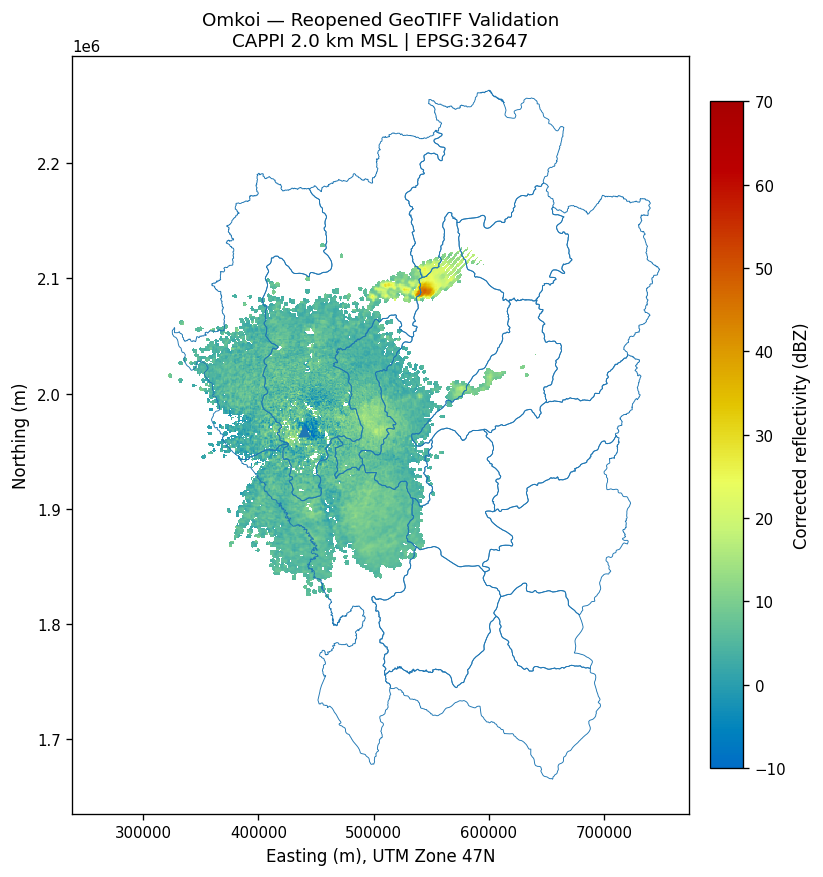

In [44]:
# CELL 44 — Replot UTM GeoTIFF independently

with rasterio.open(
    UTM_GEOTIFF
) as src:

    data_utm = src.read(
        1,
        masked=True,
    )

    bounds = src.bounds

    extent = [
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top,
    ]

    utm_crs = src.crs

adm1_utm = adm1_clip.to_crs(
    utm_crs
)

fig = plt.figure(
    figsize=(8.0, 7.2)
)

ax = fig.add_subplot(111)

image = ax.imshow(
    data_utm,
    extent=extent,
    origin="upper",
    cmap=CMAP_Z,
    vmin=ZH_VMIN,
    vmax=ZH_VMAX,
    interpolation="nearest",
)

adm1_utm.boundary.plot(
    ax=ax,
    linewidth=0.55,
)

radar_e, radar_n = (
    to_utm.transform(
        radar_lon,
        radar_lat,
    )
)

ax.scatter(
    radar_e,
    radar_n,
    marker="^",
    s=38,
)

cbar = fig.colorbar(
    image,
    ax=ax,
    pad=0.025,
    shrink=0.88,
)

cbar.set_label(
    "Corrected reflectivity (dBZ)"
)

ax.set_xlabel(
    (
        "Easting (m), UTM Zone "
        f"{UTM_INFO['zone']}"
        f"{UTM_INFO['hemisphere']}"
    )
)

ax.set_ylabel(
    "Northing (m)"
)

ax.set_title(
    (
        f"{site_name} — Reopened GeoTIFF Validation\n"
        f"CAPPI "
        f"{primary_cappi['actual_height_km_MSL']:.1f} km MSL | "
        f"EPSG:{UTM_INFO['epsg']}"
    )
)

GEOTIFF_FIG = (
    FIGURE_DIR
    / "03_fig02_GeoTIFF_UTM_validation.png"
)

save_figure(
    fig,
    GEOTIFF_FIG,
    source_file=selected_filename,
    field=FIELD_Z,
    height_msl_km=(
        primary_cappi[
            "actual_height_km_MSL"
        ]
    ),
    time_utc=utc_time,
    processing=(
        "Independent Rasterio reopen of UTM GeoTIFF; "
        "ADM1 reprojected to matching CRS."
    ),
    vmin=ZH_VMIN,
    vmax=ZH_VMAX,
    cmap=CMAP_Z,
)

plt.show()

# 29. Export grid metadata for Methods and reproducibility

In [45]:
# CELL 45 — Grid metadata

grid_metadata = pd.DataFrame({
    "parameter": [
        "source_file",
        "radar_site",
        "radar_latitude_deg",
        "radar_longitude_deg",
        "radar_altitude_m_MSL",
        "observation_time_UTC",
        "field",
        "grid_origin_altitude_m_MSL",
        "grid_nz",
        "grid_ny",
        "grid_nx",
        "grid_dx_km",
        "grid_dy_km",
        "grid_dz_km",
        "grid_z_min_km_MSL",
        "grid_z_max_km_MSL",
        "grid_half_width_km",
        "weighting_function",
        "roi_function",
        "minimum_roi_m",
        "roi_nb",
        "roi_bsp",
        "roi_h_factor",
        "gridding_seconds",
        "grid_projection",
        "UTM_zone",
        "UTM_EPSG",
        "native_AEQD_GeoTIFF",
        "UTM_GeoTIFF",
        "3D_grid_NetCDF",
    ],
    "value": [
        selected_filename,
        site_name,
        radar_lat,
        radar_lon,
        radar_alt_msl_m,
        str(utc_time),
        FIELD_Z,
        0.0,
        NZ,
        NY,
        NX,
        GRID_DX_KM,
        GRID_DY_KM,
        GRID_DZ_KM,
        GRID_Z_MIN_MSL_KM,
        GRID_Z_MAX_MSL_KM,
        GRID_HALF_WIDTH_KM,
        WEIGHTING_FUNCTION,
        ROI_FUNCTION,
        MIN_RADIUS_M,
        ROI_NB,
        ROI_BSP,
        str(ROI_H_FACTOR),
        grid_elapsed_s,
        str(
            grid.get_projparams()
        ),
        (
            f"{UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']}"
        ),
        UTM_INFO["epsg"],
        str(NATIVE_GEOTIFF),
        str(UTM_GEOTIFF),
        str(GRID_NETCDF),
    ],
})

display(grid_metadata)

GRID_METADATA_CSV = (
    OUTPUT_CSV_DIR
    / "03_grid_metadata.csv"
)

grid_metadata.to_csv(
    GRID_METADATA_CSV,
    index=False,
)

print("Saved:", GRID_METADATA_CSV)

,parameter,value
0,source_file,20230318180002.uf.gz
1,radar_site,Omkoi
2,radar_latitude_deg,17.798207
3,radar_longitude_deg,98.432326
4,radar_altitude_m_MSL,1173.0
5,observation_time_UTC,2023-03-18 18:00:02+00:00
6,field,corrected_reflectivity
7,grid_origin_altitude_m_MSL,0.0
8,grid_nz,29
9,grid_ny,401


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/03_output/csv/03_grid_metadata.csv


# 30. Export figure manifest

In [46]:
# CELL 46 — Figure manifest

figure_manifest = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "03_figure_manifest.csv"
)

figure_manifest.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(figure_manifest)

print("Saved:", FIGURE_MANIFEST_CSV)

,figure_name,figure_path,source_file,field,height_msl_km,time_UTC,processing,vmin,vmax,colormap,dpi
0,03_fig01_valid_fraction_vs_height.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,NaN,2023-03-18 18:00:02+00:00,Fraction of finite unmasked Cartesian reflecti...,NaN,NaN,None,300
1,03_CAPPI_ZH_02.0kmMSL_20230318_180002UTC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,2.0,2023-03-18 18:00:02+00:00,CAPPI extracted from 3-D Py-ART grid; Barnes2;...,-10.0,70.0,HomeyerRainbow,300
2,03_CAPPI_ZH_03.0kmMSL_20230318_180002UTC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,3.0,2023-03-18 18:00:02+00:00,CAPPI extracted from 3-D Py-ART grid; Barnes2;...,-10.0,70.0,HomeyerRainbow,300
3,03_CAPPI_ZH_04.0kmMSL_20230318_180002UTC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,4.0,2023-03-18 18:00:02+00:00,CAPPI extracted from 3-D Py-ART grid; Barnes2;...,-10.0,70.0,HomeyerRainbow,300
4,03_CAPPI_ZH_05.0kmMSL_20230318_180002UTC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,5.0,2023-03-18 18:00:02+00:00,CAPPI extracted from 3-D Py-ART grid; Barnes2;...,-10.0,70.0,HomeyerRainbow,300
5,03_CAPPI_ZH_06.0kmMSL_20230318_180002UTC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,6.0,2023-03-18 18:00:02+00:00,CAPPI extracted from 3-D Py-ART grid; Barnes2;...,-10.0,70.0,HomeyerRainbow,300
6,03_CAPPI_ZH_08.0kmMSL_20230318_180002UTC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,8.0,2023-03-18 18:00:02+00:00,CAPPI extracted from 3-D Py-ART grid; Barnes2;...,-10.0,70.0,HomeyerRainbow,300
7,03_CAPPI_ZH_10.0kmMSL_20230318_180002UTC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,10.0,2023-03-18 18:00:02+00:00,CAPPI extracted from 3-D Py-ART grid; Barnes2;...,-10.0,70.0,HomeyerRainbow,300
8,03_CAPPI_ZH_12.0kmMSL_20230318_180002UTC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,12.0,2023-03-18 18:00:02+00:00,CAPPI extracted from 3-D Py-ART grid; Barnes2;...,-10.0,70.0,HomeyerRainbow,300
9,03_CAPPI_support_02.0kmMSL.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,valid_data_support,2.0,2023-03-18 18:00:02+00:00,Binary support mask from gridded corrected ref...,0.0,1.0,Greys,300


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/03_output/csv/03_figure_manifest.csv


# 31. Methods-writing template

After running the Notebook, use `03_grid_metadata.csv` rather than memory.

Example structure:

> Radar corrected-reflectivity volumes were interpolated to a three-dimensional Cartesian grid centered on the Omkoi radar using Py-ART. The grid used explicit horizontal and vertical spacing, with altitude referenced directly to mean sea level by setting the grid-origin altitude to 0 m MSL. Barnes2 distance weighting and a distance/virtual-beam radius-of-influence formulation were applied. Grid geometry, interpolation parameters, CRS information and derived-file provenance were retained in analysis metadata.

For publication, replace general wording with the exact parameters from the exported metadata.

# 32. CORE exercises

### Exercise 1 — PPI versus CAPPI
Compare Notebook 02 sweep-0 PPI with CAPPI 2 km MSL.

Explain why their echo shapes differ.

### Exercise 2 — Vertical datum
If a default radar-relative grid had `z = 2 km ARL`, what MSL altitude would that represent at Omkoi?

### Exercise 3 — CAPPI levels
Compare 2, 4 and 6 km MSL:

- valid fraction
- maximum reflectivity
- P95 reflectivity

Do not infer severe weather solely from these three levels.

# 33. ADVANCED / MSc exercises

### Exercise 4 — ROI sensitivity
Using `03_ROI_sensitivity.csv`, explain the trade-off between:

```text
data gaps
versus
spatial smoothing
```

### Exercise 5 — Grid-spacing sensitivity
Compare 2, 1 and 0.5 km outputs.

Explain why finer pixel size does not guarantee finer observational resolution.

### Exercise 6 — CRS
Report:

- radar lon/lat
- UTM zone
- EPSG
- radar UTM easting/northing

Explain why geographic degrees should not be used directly for planar distance/area calculations.

# 34. RESEARCH exercises

### Exercise 7 — GeoTIFF validation
Open the UTM GeoTIFF using GIS software or Rasterio and verify:

- CRS
- pixel size
- bounds
- nodata
- reflectivity range

### Exercise 8 — Point extraction
Choose a geographic point and run:

```python
extract_nearest_cappi_point(...)
```

Report the distance from requested point to grid-cell center.

### Exercise 9 — Reproducible Methods
Use `03_grid_metadata.csv` to write a 100–150-word Method paragraph.

Do not add a parameter that does not appear in metadata.

# 35. Final Notebook 03 readiness check

In [47]:
# CELL 47 — Readiness check

checks = []

def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": item,
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": note,
    })


add_check(
    "Notebook 01 dataset readiness",
    bool(
        SETUP_STATUS.get(
            "ready",
            False,
        )
    ),
)

add_check(
    "Notebook 02 readiness",
    bool(
        (
            readiness_02["status"]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Selected radar readable",
    radar is not None,
)

add_check(
    "Corrected reflectivity available",
    FIELD_Z in radar.fields,
)

add_check(
    "3-D Cartesian grid created",
    grid is not None,
)

add_check(
    "Grid origin altitude is 0 m MSL",
    np.isclose(
        float(
            grid.origin_altitude[
                "data"
            ][0]
        ),
        0.0,
    ),
)

add_check(
    "Expected 3-D grid shape",
    tuple(
        grid.fields[
            FIELD_Z
        ]["data"].shape
    )
    == GRID_SHAPE,
)

add_check(
    "CAPPI summary exported",
    CAPPI_LEVEL_CSV.exists(),
)

add_check(
    "Vertical support exported",
    VERTICAL_SUPPORT_CSV.exists(),
)

add_check(
    "ROI sensitivity exported",
    ROI_EXPERIMENT_CSV.exists(),
)

add_check(
    "Grid-spacing sensitivity exported",
    SPACING_EXPERIMENT_CSV.exists(),
)

add_check(
    "Automatic UTM CRS derived",
    UTM_INFO["epsg"] > 0,
)

add_check(
    "Native AEQD GeoTIFF created",
    NATIVE_GEOTIFF.exists(),
)

add_check(
    "UTM GeoTIFF created",
    UTM_GEOTIFF.exists(),
)

add_check(
    "3-D Grid NetCDF created",
    GRID_NETCDF.exists(),
)

add_check(
    "Grid metadata exported",
    GRID_METADATA_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)

readiness_03 = pd.DataFrame(
    checks
)

display(readiness_03)

NOTEBOOK_03_READY = bool(
    (
        readiness_03["status"]
        == "PASS"
    ).all()
)

READINESS_03_CSV = (
    OUTPUT_CSV_DIR
    / "03_readiness_check.csv"
)

readiness_03.to_csv(
    READINESS_03_CSV,
    index=False,
)

print()

print(
    "NOTEBOOK 03 READY FOR QPE / POINT EXTRACTION"
    if NOTEBOOK_03_READY
    else "NOTEBOOK 03 REQUIRES REVIEW"
)

,item,status,note
0,Notebook 01 dataset readiness,PASS,
1,Notebook 02 readiness,PASS,
2,Selected radar readable,PASS,
3,Corrected reflectivity available,PASS,
4,3-D Cartesian grid created,PASS,
5,Grid origin altitude is 0 m MSL,PASS,
6,Expected 3-D grid shape,PASS,
7,CAPPI summary exported,PASS,
8,Vertical support exported,PASS,
9,ROI sensitivity exported,PASS,



NOTEBOOK 03 READY FOR QPE / POINT EXTRACTION


# Key messages

1. **Polar gates are observations; Cartesian pixels are interpolated products.**
2. Grid spacing is not radar observational resolution.
3. Along-beam and cross-beam sampling differ.
4. `PPI ≠ CAPPI`.
5. CAPPI is constant altitude but remains an interpolation.
6. `ARL ≠ MSL ≠ AGL`.
7. This Notebook uses `grid_origin_alt = 0 m MSL`, so `grid.z` is directly MSL.
8. ROI and weighting influence smoothing and gaps.
9. CAPPI interpretation should include a data-support diagnostic.
10. A finer Cartesian grid does not create new radar information.
11. Radar Cartesian, geographic and UTM coordinates are distinct representations.
12. UTM zone is derived from location, not hard-coded.
13. GeoTIFF is first written in native radar Cartesian projection and then explicitly reprojected.
14. Reopening GeoTIFF independently is part of validation.
15. Point extraction from CAPPI returns an interpolated grid value.
16. The saved 3-D NetCDF Grid is the bridge to QPE and severe-storm analysis.

# Expected outputs

```text
03_output/csv/
├── 03_vertical_valid_fraction.csv
├── 03_CAPPI_level_summary.csv
├── 03_ROI_sensitivity.csv
├── 03_grid_spacing_sensitivity.csv
├── 03_grid_metadata.csv
├── 03_figure_manifest.csv
└── 03_readiness_check.csv

03_output/geotiff/
├── 03_CAPPI_ZH_2.0kmMSL_native_AEQD.tif
└── 03_CAPPI_ZH_2.0kmMSL_UTM47N.tif

03_output/netcdf/
└── 03_Omkoi_3D_grid_*UTC_corrected_reflectivity.nc

04_figures/03/
├── valid-fraction-vs-height
├── CAPPI 2/3/4/5/6/8/10/12 km MSL
├── selected CAPPI support maps
├── ROI-sensitivity figures
├── grid-spacing sensitivity figures
└── UTM GeoTIFF validation
```

When the final message is:

```text
NOTEBOOK 03 READY FOR QPE / POINT EXTRACTION
```

continue to:

**Notebook 04 — Reflectivity–Rainfall QPE, Z–R Relations and Spatial Point Extraction**

# Technical references

Core software concepts used in this Notebook:

- Py-ART `grid_from_radars`
- Py-ART `map_gates_to_grid`
- Barnes2 weighting
- `dist_beam` radius of influence
- Py-ART Grid geographic transformation
- Rasterio GeoTIFF writing and reprojection
- WGS84 / UTM projected coordinates

For research publication, cite the radar-processing software and report the actual grid geometry, vertical reference, weighting and ROI parameters used in the final analysis.